In [4]:
import re
import pandas as pd
import numpy as np
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

import pandas as pd
import numpy as np
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

In [5]:
# ─────────────────────────────────────────────
# STEP 0 — LOAD RAW DATA
# ─────────────────────────────────────────────
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipent(opal).xlsx")
print(f"[Step 0] Raw data loaded: {df.shape[0]} rows × {df.shape[1]} cols")

[Step 0] Raw data loaded: 800 rows × 14 cols


In [6]:
# ─────────────────────────────────────────────
# STEP 1 — DROP UNNECESSARY / PII COLUMNS
# ─────────────────────────────────────────────
# Drop name and contact columns (PII, not useful for ML/analysis)
pii_cols = ["first_name", "last_name", "contact_number", "recipient_id"]
df.drop(columns=pii_cols, inplace=True)
print(f"[Step 1] Dropped PII columns: {pii_cols}")

[Step 1] Dropped PII columns: ['first_name', 'last_name', 'contact_number', 'recipient_id']


In [7]:
# ─────────────────────────────────────────────
# STEP 2 — STANDARDISE TEXT COLUMNS
# ─────────────────────────────────────────────
str_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
for col in str_cols:
    df[col] = df[col].str.strip()

# Standardise organ names to match donor dataset
organ_map = {"Corneas": "Cornea", "Lungs": "Lung"}
df["required_organ"] = df["required_organ"].replace(organ_map)
print("[Step 2] Standardised text columns and organ names")

[Step 2] Standardised text columns and organ names


In [8]:
# ─────────────────────────────────────────────
# STEP 3 — DATETIME FEATURE EXTRACTION
# ─────────────────────────────────────────────
df["time_got"] = pd.to_datetime(df["time_got"])
df["wait_hour"]  = df["time_got"].dt.hour
df["wait_day"]   = df["time_got"].dt.dayofweek   # 0 = Monday
df["wait_month"] = df["time_got"].dt.month
df.drop(columns=["time_got"], inplace=True)
print("[Step 3] Extracted datetime features: wait_hour, wait_day, wait_month")

[Step 3] Extracted datetime features: wait_hour, wait_day, wait_month


In [9]:
# ─────────────────────────────────────────────
# STEP 4 — HANDLE MISSING VALUES
# ─────────────────────────────────────────────
# medical_conditions → fill NaN with 'None'
df["medical_conditions"] = df["medical_conditions"].fillna("None")

# cancer_stage → fill NaN with 'No Cancer' (majority class)
df["cancer_stage"] = df["cancer_stage"].fillna("No Cancer")
print("[Step 4] Filled missing values:")
print(f"         medical_conditions NaN → 'None'")
print(f"         cancer_stage NaN      → 'No Cancer'")

[Step 4] Filled missing values:
         medical_conditions NaN → 'None'
         cancer_stage NaN      → 'No Cancer'


In [10]:
# ─────────────────────────────────────────────
# STEP 5 — ENCODE BINARY COLUMNS
# ─────────────────────────────────────────────
# gender
df["gender_Male"] = (df["gender"] == "Male").astype(int)
df.drop(columns=["gender"], inplace=True)

# hepatitis_status
df["hepatitis_positive"] = (df["hepatitis_status"] == "Positive").astype(int)
df.drop(columns=["hepatitis_status"], inplace=True)

print("[Step 5] Binary encoded: gender → gender_Male, hepatitis_status → hepatitis_positive")

[Step 5] Binary encoded: gender → gender_Male, hepatitis_status → hepatitis_positive


In [11]:
# ─────────────────────────────────────────────
# STEP 6 — ONE-HOT ENCODE BLOOD TYPE
# ─────────────────────────────────────────────
blood_dummies = pd.get_dummies(df["blood_type"], prefix="blood").astype(int)
df = pd.concat([df.drop(columns=["blood_type"]), blood_dummies], axis=1)
print(f"[Step 6] One-hot encoded blood_type → {list(blood_dummies.columns)}")

[Step 6] One-hot encoded blood_type → ['blood_A+', 'blood_A-', 'blood_AB+', 'blood_AB-', 'blood_B+', 'blood_B-', 'blood_O+', 'blood_O-']


In [12]:
# ─────────────────────────────────────────────
# STEP 7 — ONE-HOT ENCODE REQUIRED ORGAN
# ─────────────────────────────────────────────
organ_dummies = pd.get_dummies(df["required_organ"], prefix="Organ").astype(int)
df = pd.concat([df.drop(columns=["required_organ"]), organ_dummies], axis=1)
print(f"[Step 7] One-hot encoded required_organ → {list(organ_dummies.columns)}")

[Step 7] One-hot encoded required_organ → ['Organ_Cornea', 'Organ_Heart', 'Organ_Kidney', 'Organ_Liver', 'Organ_Lung', 'Organ_Pancreas']


In [13]:

# ─────────────────────────────────────────────
# STEP 8 — ENCODE MEDICAL CONDITIONS (multi-label)
# ─────────────────────────────────────────────
# Major condition groups (mirrors donor Condition_ columns)
condition_groups = {
    "Condition_Diabetes":       ["Diabetes", "Diabetic Nephropathy"],
    "Condition_Hypertension":   ["Hypertension", "Portal Hypertension",
                                 "Pulmonary Hypertension", "Hypertensive Nephropathy",
                                 "Renal Artery Stenosis"],
    "Condition_Heart_Disease":  ["Heart Disease", "Heart Failure", "Cardiomyopathy",
                                 "Cardiac Arrhythmia", "Myocarditis", "Cardiomegaly"],
    "Condition_Asthma":         ["Asthma", "COPD", "Bronchiectasis", "Bronchitis",
                                 "Cystic Fibrosis", "Pulmonary Fibrosis",
                                 "Interstitial Lung Disease", "Restrictive Lung Disease",
                                 "Pulmonary Embolism", "Pneumoconiosis", "Pneumonia",
                                 "Sarcoidosis"],
    "Condition_Liver_Disease":  ["Cirrhosis", "Hepatitis B", "Hepatitis C", "Hepatitis D",
                                 "Hepatitis E", "Hepatitis A", "Liver Disease",
                                 "Liver Cirrhosis", "Liver Fibrosis", "Acute Liver Failure",
                                 "Alcoholic Liver Disease", "Alcohol-related Liver Disease",
                                 "Autoimmune Hepatitis", "Primary Biliary Cirrhosis",
                                 "Primary Biliary Cholangitis", "Primary Sclerosing Cholangitis",
                                 "Wilson's Disease", "Gilbert's Syndrome", "Alagille Syndrome"],
    "Condition_Kidney_Disease": ["Renal Failure", "Renal Cysts", "Renal Tubular Acidosis",
                                 "Chronic Kidney Disease", "Polycystic Kidney Disease",
                                 "Glomerulonephritis", "Glomerulosclerosis", "FSGS",
                                 "IgA Nephropathy", "Alport Syndrome"],
}

for col, keywords in condition_groups.items():
    pattern = "|".join([re.escape(k) for k in keywords])
    df[col] = df["medical_conditions"].str.contains(pattern, na=False).astype(int)

print(f"[Step 8] Multi-label encoded medical_conditions → {list(condition_groups.keys())}")

[Step 8] Multi-label encoded medical_conditions → ['Condition_Diabetes', 'Condition_Hypertension', 'Condition_Heart_Disease', 'Condition_Asthma', 'Condition_Liver_Disease', 'Condition_Kidney_Disease']


In [14]:
# ─────────────────────────────────────────────
# STEP 9 — ENCODE CANCER STAGE (ordinal)
# ─────────────────────────────────────────────
cancer_map = {"No Cancer": 0, "Stage 1": 1, "Stage 2": 2, "Stage 3": 3}
df["cancer_stage_encoded"] = df["cancer_stage"].map(cancer_map)
df.drop(columns=["cancer_stage"], inplace=True)
print(f"[Step 9] Ordinal encoded cancer_stage → cancer_stage_encoded {cancer_map}")

[Step 9] Ordinal encoded cancer_stage → cancer_stage_encoded {'No Cancer': 0, 'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3}


In [15]:
# ─────────────────────────────────────────────
# STEP 10 — ENCODE HOSPITAL (label encode)
# ─────────────────────────────────────────────
hospital_codes = {h: i for i, h in enumerate(sorted(df["hospital_name"].unique()))}
df["hospital_encoded"] = df["hospital_name"].map(hospital_codes)
df.drop(columns=["hospital_name"], inplace=True)
print(f"[Step 10] Label encoded hospital_name → hospital_encoded ({len(hospital_codes)} hospitals)")

[Step 10] Label encoded hospital_name → hospital_encoded (84 hospitals)


In [16]:
# ─────────────────────────────────────────────
# STEP 11 — ONE-HOT ENCODE CITY
# ─────────────────────────────────────────────
city_dummies = pd.get_dummies(df["city"], prefix="City").astype(int)
df = pd.concat([df.drop(columns=["city"]), city_dummies], axis=1)
print(f"[Step 11] One-hot encoded city → {list(city_dummies.columns)}")

[Step 11] One-hot encoded city → ['City_Abbottabad', 'City_Bahawalpur', 'City_Dera Ghazi Khan', 'City_Faisalabad', 'City_Gujranwala', 'City_Hyderabad', 'City_Islamabad', 'City_Jhelum', 'City_Karachi', 'City_Lahore', 'City_Mardan', 'City_Mirpur AK', 'City_Multan', 'City_Okara', 'City_Peshawar', 'City_Quetta', 'City_Rawalpindi', 'City_Sahiwal', 'City_Sargodha', 'City_Sialkot']


In [17]:
# ─────────────────────────────────────────────
# STEP 12 — DROP RAW TEXT COLUMNS
# ─────────────────────────────────────────────
df.drop(columns=["medical_conditions"], inplace=True)
print("[Step 12] Dropped raw medical_conditions column (encoded version kept)")

[Step 12] Dropped raw medical_conditions column (encoded version kept)


In [18]:
# ─────────────────────────────────────────────
# STEP 13 — FINAL COLUMN ORDER & SUMMARY
# ─────────────────────────────────────────────
print(f"\n[Step 13] Final dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print("Columns:", list(df.columns))
print("\nMissing values after preprocessing:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else "  None ✓")
print("\nData types:")
print(df.dtypes.value_counts())


[Step 13] Final dataset: 800 rows × 48 columns
Columns: ['age', 'wait_hour', 'wait_day', 'wait_month', 'gender_Male', 'hepatitis_positive', 'blood_A+', 'blood_A-', 'blood_AB+', 'blood_AB-', 'blood_B+', 'blood_B-', 'blood_O+', 'blood_O-', 'Organ_Cornea', 'Organ_Heart', 'Organ_Kidney', 'Organ_Liver', 'Organ_Lung', 'Organ_Pancreas', 'Condition_Diabetes', 'Condition_Hypertension', 'Condition_Heart_Disease', 'Condition_Asthma', 'Condition_Liver_Disease', 'Condition_Kidney_Disease', 'cancer_stage_encoded', 'hospital_encoded', 'City_Abbottabad', 'City_Bahawalpur', 'City_Dera Ghazi Khan', 'City_Faisalabad', 'City_Gujranwala', 'City_Hyderabad', 'City_Islamabad', 'City_Jhelum', 'City_Karachi', 'City_Lahore', 'City_Mardan', 'City_Mirpur AK', 'City_Multan', 'City_Okara', 'City_Peshawar', 'City_Quetta', 'City_Rawalpindi', 'City_Sahiwal', 'City_Sargodha', 'City_Sialkot']

Missing values after preprocessing:
  None ✓

Data types:
int64    45
int32     3
Name: count, dtype: int64


In [19]:
# ─────────────────────────────────────────────
# STEP 14 — SAVE PREPROCESSED CSV (fast backup)
# ─────────────────────────────────────────────
df.to_csv("recipient_preprocessed.csv", index=False)
print("\n[Step 14] Saved: recipient_preprocessed.csv")


[Step 14] Saved: recipient_preprocessed.csv


In [22]:
# ─────────────────────────────────────────────
# STEP 15 — SAVE PROFESSIONALLY FORMATTED XLSX
# ─────────────────────────────────────────────
raw_df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipent(opal).xlsx")

output_path = r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    # Sheet 1: Preprocessed encoded data
    df.to_excel(writer, sheet_name="Preprocessed_Data", index=False)

    # Sheet 2: Original raw data (for reference)
    raw_df.to_excel(writer, sheet_name="Raw_Data", index=False)

    # Sheet 3: Encoding reference / data dictionary
    ref_rows = []
    ref_rows.append(["Column", "Type", "Description"])
    ref_rows.append(["age", "int", "Age of recipient"])
    ref_rows.append(["gender_Male", "binary 0/1", "1=Male, 0=Female"])
    ref_rows.append(["hepatitis_positive", "binary 0/1", "1=Positive, 0=Negative"])
    ref_rows.append(["wait_hour", "int 0-23", "Hour extracted from time_got"])
    ref_rows.append(["wait_day", "int 0-6", "Day of week (0=Mon) from time_got"])
    ref_rows.append(["wait_month", "int 1-12", "Month extracted from time_got"])
    ref_rows.append(["cancer_stage_encoded", "ordinal 0-3", "0=No Cancer, 1=Stage 1, 2=Stage 2, 3=Stage 3"])
    ref_rows.append(["hospital_encoded", "int", "Label encoded hospital name"])
    for bt in ["A+","A-","AB+","AB-","B+","B-","O+","O-"]:
        ref_rows.append([f"blood_{bt}", "binary 0/1", f"1 if blood type is {bt}"])
    for org in ["Cornea","Heart","Kidney","Liver","Lung","Pancreas"]:
        ref_rows.append([f"Organ_{org}", "binary 0/1", f"1 if required organ is {org}"])
    for cond in condition_groups.keys():
        ref_rows.append([cond, "binary 0/1", f"1 if condition group present"])
    for city in sorted(raw_df["city"].unique()):
        ref_rows.append([f"City_{city}", "binary 0/1", f"1 if recipient is from {city}"])
    
    ref_df = pd.DataFrame(ref_rows[1:], columns=ref_rows[0])
    ref_df.to_excel(writer, sheet_name="Data_Dictionary", index=False)

# ── Apply formatting ──
wb = load_workbook(output_path)

header_font  = Font(name="Arial", bold=True, color="FFFFFF", size=10)
header_fill  = PatternFill("solid", start_color="1F4E79")
alt_fill     = PatternFill("solid", start_color="D6E4F0")
center_align = Alignment(horizontal="center", vertical="center")
left_align   = Alignment(horizontal="left",   vertical="center")
thin_border  = Border(
    left=Side(style="thin"), right=Side(style="thin"),
    top=Side(style="thin"),  bottom=Side(style="thin")
)

def style_sheet(ws, col_widths=None):
    for cell in ws[1]:
        cell.font      = header_font
        cell.fill      = header_fill
        cell.alignment = center_align
        cell.border    = thin_border

    for i, row in enumerate(ws.iter_rows(min_row=2), start=2):
        fill = alt_fill if i % 2 == 0 else PatternFill()
        for cell in row:
            cell.fill      = fill
            cell.alignment = left_align
            cell.border    = thin_border
            cell.font      = Font(name="Arial", size=9)

    if col_widths:
        for col_letter, width in col_widths.items():
            ws.column_dimensions[col_letter].width = width
    else:
        for col in ws.columns:
            max_len = max((len(str(c.value)) for c in col if c.value), default=8)
            ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 30)

    ws.freeze_panes = "A2"

# Style all sheets
for sheet_name in wb.sheetnames:
    style_sheet(wb[sheet_name])

# Widen Data_Dictionary columns
ws_dict = wb["Data_Dictionary"]
ws_dict.column_dimensions["A"].width = 30
ws_dict.column_dimensions["B"].width = 18
ws_dict.column_dimensions["C"].width = 50

wb.save(output_path)
print(f"[Step 15] Saved: {output_path}  ✓")
print("\n=== PREPROCESSING COMPLETE ===")

[Step 15] Saved: E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL.xlsx  ✓

=== PREPROCESSING COMPLETE ===


---
# 📊 Complete EDA — Organ Transplant Recipient Dataset
> 800 Recipients · 48 Features · Pakistan Healthcare Data

| Section | Plots |
|---------|-------|
| Univariate | Histograms, KDE, Boxplots, Countplots, % bars |
| Bivariate | Correlation heatmap, Scatter, Pairplot, Grouped boxes |
| Multivariate | Full heatmap, Violin, Grouped bars |
| Advanced | Class imbalance, KDE overlays, Feature-target, Dashboard |

---

## ⚙️ Setup — Imports & Style

In [23]:
%matplotlib inline
import warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

# ── Global style ─────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#F8F9FA",
    "axes.edgecolor"   : "#CCCCCC",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.titlepad"    : 10,
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "legend.fontsize"  : 9,
    "legend.framealpha": 0.85,
    "grid.color"       : "#E5E5E5",
    "grid.linewidth"   : 0.6,
})

C_BLUE   = "#2C6FAC"
C_RED    = "#D94F3D"
C_GREEN  = "#3A9E5F"
C_ORANGE = "#E5843A"
C_TEAL   = "#2B9EB3"
GENDER_PALETTE = {"Male": C_BLUE, "Female": C_ORANGE}
print("✔ Imports & style configured")

✔ Imports & style configured


## 📂 Data Loading & Column Detection

In [25]:
df = pd.read_excel(
    r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx",
    sheet_name="Preprocessed_Data"
)
print(f"Shape  : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing: {df.isnull().sum().sum()} values")

# Auto-detect column groups
all_num   = df.select_dtypes(include=np.number).columns.tolist()
bin_cols  = [c for c in all_num if df[c].nunique() == 2]
cont_cols = [c for c in all_num if c not in bin_cols]
ORGAN_COLS = [c for c in df.columns if c.startswith("Organ_")]
BLOOD_COLS = [c for c in df.columns if c.startswith("blood_")]
CITY_COLS  = [c for c in df.columns if c.startswith("City_")]
COND_COLS  = [c for c in df.columns if c.startswith("Condition_")]
CORE_CONT  = ["age","wait_hour","wait_day","wait_month","cancer_stage_encoded","hospital_encoded"]
stage_map  = {0:"No Cancer", 1:"Stage 1", 2:"Stage 2", 3:"Stage 3"}
stage_order= ["No Cancer","Stage 1","Stage 2","Stage 3"]

def label(col):
    return col.replace("_"," ").replace("blood ","").replace("Organ ","").replace("City ","").replace("Condition ","").title()

print(f"\nContinuous cols : {CORE_CONT}")
print(f"Binary/OHE cols : {len(bin_cols)}")
df.head(3)

Shape  : 800 rows x 48 columns
Missing: 0 values

Continuous cols : ['age', 'wait_hour', 'wait_day', 'wait_month', 'cancer_stage_encoded', 'hospital_encoded']
Binary/OHE cols : 42


,age,wait_hour,wait_day,wait_month,gender_Male,hepatitis_positive,blood_A+,blood_A-,blood_AB+,blood_AB-,...,City_Mardan,City_Mirpur AK,City_Multan,City_Okara,City_Peshawar,City_Quetta,City_Rawalpindi,City_Sahiwal,City_Sargodha,City_Sialkot
0,45,14,5,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,52,9,0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,28,11,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


---
## 📈 Section 1 — Univariate Analysis

### 1.1 Histograms + KDE — Continuous Features

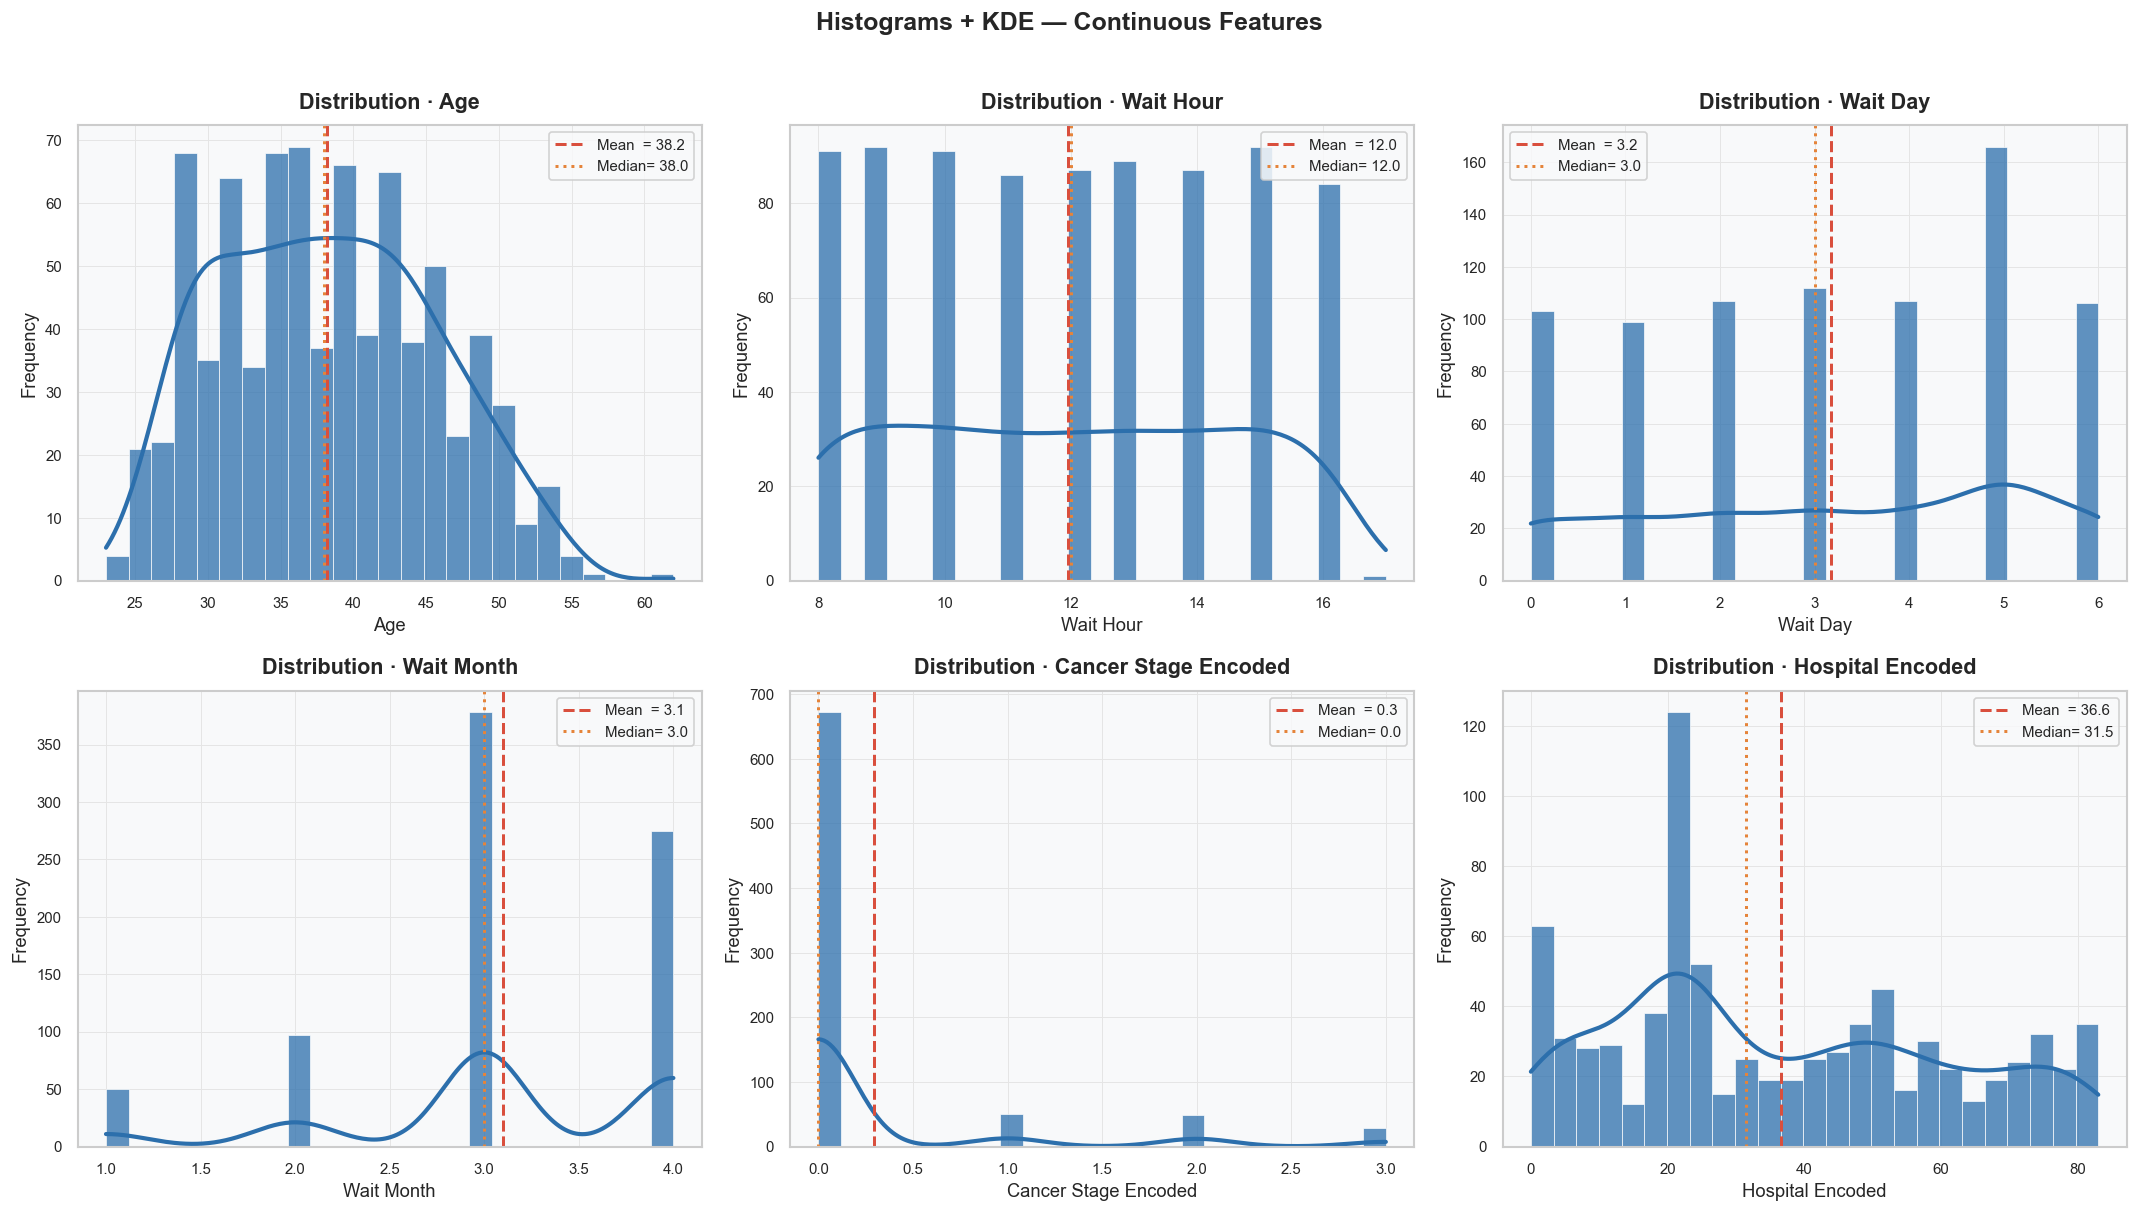

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(CORE_CONT):
    ax = axes[i]
    mean_v, med_v = df[col].mean(), df[col].median()
    sns.histplot(df[col], kde=True, ax=ax, color=C_BLUE,
                 bins=25, edgecolor="white", linewidth=0.4, alpha=0.75,
                 line_kws={"linewidth": 2.5, "color": C_TEAL})
    ax.axvline(mean_v,  color=C_RED,    linestyle="--", lw=1.8, label=f"Mean  = {mean_v:.1f}")
    ax.axvline(med_v,   color=C_ORANGE, linestyle=":",  lw=1.8, label=f"Median= {med_v:.1f}")
    ax.set_title(f"Distribution · {label(col)}")
    ax.set_xlabel(label(col))
    ax.set_ylabel("Frequency")
    ax.legend()
fig.suptitle("Histograms + KDE — Continuous Features", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 1.2 Boxplots — Outlier Detection

In [ ]:
fig, axes = plt.subplots(1, len(CORE_CONT), figsize=(20, 6))
for ax, col in zip(axes, CORE_CONT):
    sns.boxplot(y=df[col], ax=ax, width=0.55, color="#AED6F1",
                medianprops=dict(color=C_RED, linewidth=2.5),
                whiskerprops=dict(color="#555", linewidth=1.2),
                capprops=dict(color="#555", linewidth=1.5),
                flierprops=dict(marker="o", markersize=4, markerfacecolor=C_RED, alpha=0.5, linestyle="none"))
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    n_out = ((df[col] < (q1-1.5*(q3-q1))) | (df[col] > (q3+1.5*(q3-q1)))).sum()
    ax.set_title(label(col))
    ax.text(0.5, 0.02, f"{n_out} outliers", transform=ax.transAxes, ha="center",
            fontsize=8, color=C_RED if n_out > 0 else C_GREEN,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))
fig.suptitle("Boxplots — Outlier Detection", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.3 Required Organ Distribution

In [ ]:
organ_series = pd.Series({c.replace("Organ_",""):df[c].sum() for c in ORGAN_COLS}).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette("Set2", len(organ_series))
bars = axes[0].bar(organ_series.index, organ_series.values, color=colors, edgecolor="white", width=0.65)
for bar, val in zip(bars, organ_series.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Required Organ Distribution"); axes[0].set_xlabel("Organ"); axes[0].set_ylabel("Count")
axes[0].set_ylim(0, organ_series.max()*1.2); axes[0].tick_params(axis="x", rotation=20)
axes[1].pie(organ_series.values, labels=organ_series.index, autopct="%1.1f%%", colors=colors,
            startangle=140, pctdistance=0.75, wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Organ Demand Share")
fig.suptitle("Required Organ Distribution", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.4 Blood Type Distribution

In [ ]:
blood_series = pd.Series({c.replace("blood_",""):df[c].sum() for c in BLOOD_COLS}).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(blood_series.index, blood_series.values,
              color=sns.color_palette("Blues_r", len(blood_series)), edgecolor="white", width=0.65)
for bar, val in zip(bars, blood_series.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Blood Type Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Blood Type"); ax.set_ylabel("Count")
ax.set_ylim(0, blood_series.max()*1.22)
plt.tight_layout()
plt.show()

### 1.5 Value-Count % — Gender, Hepatitis, Cancer Stage

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Gender
g_data = pd.Series({"Male":df["gender_Male"].sum(), "Female":(df["gender_Male"]==0).sum()})
bars = axes[0].bar(g_data.index, g_data.values/len(df)*100, color=[C_BLUE,C_ORANGE], edgecolor="white", width=0.5)
for bar, val in zip(bars, g_data.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[0].set_ylim(0,70); axes[0].set_title("Gender Distribution"); axes[0].set_ylabel("(%)")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
# Hepatitis
h_data = pd.Series({"Positive":df["hepatitis_positive"].sum(), "Negative":(df["hepatitis_positive"]==0).sum()})
bars = axes[1].bar(h_data.index, h_data.values/len(df)*100, color=[C_RED,C_GREEN], edgecolor="white", width=0.5)
for bar, val in zip(bars, h_data.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[1].set_ylim(0,90); axes[1].set_title("Hepatitis Status"); axes[1].set_ylabel("(%)")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
# Cancer stage
s_data = df["cancer_stage_encoded"].value_counts().sort_index()
s_data.index = [stage_map[i] for i in s_data.index]
bars = axes[2].bar(s_data.index, s_data.values/len(df)*100,
                   color=[C_GREEN,C_ORANGE,C_RED,"#8B0000"], edgecolor="white", width=0.6)
for bar, val in zip(bars, s_data.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[2].set_ylim(0,100); axes[2].set_title("Cancer Stage"); axes[2].set_ylabel("(%)")
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter()); axes[2].tick_params(axis="x",rotation=15)
fig.suptitle("Value-Count Percentages — Binary & Ordinal Features", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.6 Medical Conditions Prevalence

In [ ]:
cond_pct = pd.Series({c.replace("Condition_","").replace("_"," "):df[c].mean()*100 for c in COND_COLS}).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cond_pct.index, cond_pct.values,
               color=sns.color_palette("RdYlGn_r", len(cond_pct)), edgecolor="white", height=0.65)
for bar, val in zip(bars, cond_pct.values):
    ax.text(val+0.2, bar.get_y()+bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, cond_pct.max()*1.2)
ax.set_title("Medical Conditions Prevalence (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Percentage of Recipients (%)")
plt.tight_layout()
plt.show()

### 1.7 City Distribution

In [ ]:
city_series = pd.Series({c.replace("City_",""):df[c].sum() for c in CITY_COLS}).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(city_series.index, city_series.values,
              color=sns.color_palette("viridis", len(city_series)), edgecolor="white", width=0.7)
for bar, val in zip(bars, city_series.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(val), ha="center", va="bottom", fontsize=8)
ax.set_title("Recipient City Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("City"); ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

### 1.8 Temporal Registration Patterns

In [ ]:
day_map   = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, cmap_, xmap) in zip(axes, [
        ("wait_hour","Blues",None), ("wait_day","Greens",day_map), ("wait_month","Oranges",month_map)]):
    counts = df[col].value_counts().sort_index()
    xlabels = [xmap[k] if xmap else k for k in counts.index]
    ax.bar(xlabels, counts.values, color=sns.color_palette(cmap_, len(counts))[::-1], edgecolor="white", width=0.7)
    ax.set_title(f"Registration by {col.replace('_',' ').title()}")
    ax.set_xlabel(col.replace("_"," ").title()); ax.set_ylabel("Count")
    if xmap: ax.tick_params(axis="x", rotation=30)
fig.suptitle("Temporal Registration Patterns", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 🔍 Section 2 — Bivariate Analysis

### 2.1 Correlation Heatmap — Core + Clinical Features

In [ ]:
HEAT_COLS = CORE_CONT + ["gender_Male","hepatitis_positive"] + COND_COLS
corr = df[HEAT_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            annot_kws={"size":8,"weight":"bold"},
            cbar_kws={"shrink":0.75,"label":"Pearson r"}, ax=ax)
ax.set_title("Correlation Heatmap — Core + Clinical Features", fontsize=13, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=40); ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

### 2.2 Scatterplots — Key Numerical Pairs (by Gender)

In [ ]:
pairs = [("age","cancer_stage_encoded","Age","Cancer Stage"),
         ("age","wait_hour","Age","Registration Hour"),
         ("age","hospital_encoded","Age","Hospital (Encoded)")]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (cx,cy,lx,ly) in zip(axes, pairs):
    for gender, gdf in df.groupby("gender_Male"):
        gname = "Male" if gender==1 else "Female"
        ax.scatter(gdf[cx], gdf[cy], color=GENDER_PALETTE[gname], alpha=0.45, s=20, edgecolors="none", label=gname)
    z = np.polyfit(df[cx], df[cy], 1)
    xline = np.linspace(df[cx].min(), df[cx].max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), color="black", lw=1.5, linestyle="--", alpha=0.7)
    ax.set_xlabel(lx); ax.set_ylabel(ly); ax.set_title(f"{lx} vs {ly}"); ax.legend(title="Gender", title_fontsize=8)
fig.suptitle("Scatterplots — Coloured by Gender · Trend Line in Black", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 Pairplot — Key Continuous Features

In [ ]:
pair_df = df[["age","wait_hour","cancer_stage_encoded","hospital_encoded","gender_Male"]].copy()
pair_df["Gender"] = pair_df["gender_Male"].map({1:"Male",0:"Female"})
g = sns.pairplot(pair_df.drop(columns="gender_Male"), hue="Gender", palette=GENDER_PALETTE,
                 diag_kind="kde", plot_kws={"alpha":0.45,"s":15,"edgecolor":"none"},
                 diag_kws={"linewidth":2,"fill":True,"alpha":0.4}, corner=True)
g.figure.suptitle("Pairplot — Key Continuous Features by Gender", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.4 Age Distribution by Required Organ

In [ ]:
rows = [{"Organ":c.replace("Organ_",""), "Age":v} for c in ORGAN_COLS for v in df.loc[df[c]==1,"age"]]
odf = pd.DataFrame(rows)
order = odf.groupby("Organ")["Age"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=odf, x="Organ", y="Age", order=order, palette="Set2", width=0.55, ax=ax,
            medianprops=dict(color="red",linewidth=2),
            flierprops=dict(marker="o",markersize=4,alpha=0.4,color=C_RED))
sns.stripplot(data=odf, x="Organ", y="Age", order=order, color="gray", alpha=0.2, size=3, jitter=True, ax=ax)
ax.set_title("Age Distribution by Required Organ", fontsize=13, fontweight="bold")
ax.set_xlabel("Organ"); ax.set_ylabel("Age")
plt.tight_layout()
plt.show()

### 2.5 Age Distribution by Cancer Stage

In [ ]:
sdf = df[["age","cancer_stage_encoded"]].copy()
sdf["Cancer Stage"] = sdf["cancer_stage_encoded"].map(stage_map)
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=sdf, x="Cancer Stage", y="age", order=stage_order,
            palette=[C_GREEN,C_ORANGE,C_RED,"#8B0000"], width=0.5, ax=ax,
            medianprops=dict(color="white",linewidth=2.5))
sns.stripplot(data=sdf, x="Cancer Stage", y="age", order=stage_order,
              color="black", alpha=0.15, size=3, jitter=True, ax=ax)
ax.set_title("Age Distribution by Cancer Stage", fontsize=13, fontweight="bold")
ax.set_xlabel("Cancer Stage"); ax.set_ylabel("Age")
plt.tight_layout()
plt.show()

### 2.6 Hepatitis Status by Required Organ

In [ ]:
hep_by = {c.replace("Organ_",""):{"Positive":df[df[c]==1]["hepatitis_positive"].mean()*100,
           "Negative":(1-df[df[c]==1]["hepatitis_positive"].mean())*100} for c in ORGAN_COLS}
hdf = pd.DataFrame(hep_by).T.sort_values("Positive",ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
hdf[["Negative","Positive"]].plot(kind="bar", stacked=True, ax=ax,
    color=[C_GREEN,C_RED], edgecolor="white", linewidth=0.6, width=0.65)
for i,(idx,row) in enumerate(hdf.iterrows()):
    ax.text(i, 103, f"{row['Positive']:.1f}%", ha="center", fontsize=9, color=C_RED, fontweight="bold")
ax.set_ylim(0,115); ax.set_title("Hepatitis Status by Organ", fontsize=13, fontweight="bold")
ax.set_xlabel("Organ"); ax.set_ylabel("(%)"); ax.tick_params(axis="x",rotation=20)
ax.legend(["Hepatitis Negative","Hepatitis Positive"])
plt.tight_layout()
plt.show()

### 2.7 Medical Conditions Prevalence by Gender

In [ ]:
cg = {c.replace("Condition_","").replace("_"," "):
      {"Male":df.loc[df["gender_Male"]==1,c].mean()*100, "Female":df.loc[df["gender_Male"]==0,c].mean()*100}
      for c in COND_COLS}
cg_df = pd.DataFrame(cg).T
x = np.arange(len(cg_df)); w = 0.36
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x-w/2, cg_df["Male"],   w, color=C_BLUE,   label="Male",   edgecolor="white")
b2 = ax.bar(x+w/2, cg_df["Female"], w, color=C_ORANGE, label="Female", edgecolor="white")
for bar in [*b1,*b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(cg_df.index, rotation=20)
ax.set_title("Conditions Prevalence by Gender", fontsize=13, fontweight="bold")
ax.set_xlabel("Condition"); ax.set_ylabel("Prevalence (%)"); ax.legend()
plt.tight_layout()
plt.show()

---
## 🌐 Section 3 — Multivariate Analysis

### 3.1 Full Correlation Matrix — All 48 Features

In [ ]:
corr_full = df[all_num].corr()
mask_full = np.triu(np.ones_like(corr_full, dtype=bool))
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(corr_full, mask=mask_full, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.2, linecolor="white", annot=False,
            cbar_kws={"shrink":0.55,"label":"Pearson r"}, ax=ax)
ax.set_title("Full Correlation Matrix — All 48 Features", fontsize=14, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=90, labelsize=7); ax.tick_params(axis="y", rotation=0, labelsize=7)
plt.tight_layout()
plt.show()

### 3.2 Violin — Age by Organ × Hepatitis Status

In [ ]:
rows2 = []
for c in ORGAN_COLS:
    sub = df[df[c]==1][["age","hepatitis_positive"]].copy()
    sub["Organ"] = c.replace("Organ_","")
    sub["Hepatitis"] = sub["hepatitis_positive"].map({1:"Positive",0:"Negative"})
    rows2.append(sub)
olong = pd.concat(rows2, ignore_index=True)
ov_order = olong.groupby("Organ")["age"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(14, 7))
sns.violinplot(data=olong, x="Organ", y="age", hue="Hepatitis",
               palette={"Positive":C_RED,"Negative":C_TEAL},
               order=ov_order, split=True, inner="quart", linewidth=1.2, ax=ax)
ax.set_title("Age by Organ & Hepatitis Status (Split Violin)", fontsize=13, fontweight="bold")
ax.set_xlabel("Organ"); ax.set_ylabel("Age"); ax.legend(title="Hepatitis", loc="upper left")
plt.tight_layout()
plt.show()

NameError: name 'ORGAN_COLS' is not defined

### 3.3 Violin — Age by Cancer Stage × Gender

In [ ]:
stdf = df[["age","cancer_stage_encoded","gender_Male"]].copy()
stdf["Cancer Stage"] = stdf["cancer_stage_encoded"].map(stage_map)
stdf["Gender"] = stdf["gender_Male"].map({1:"Male",0:"Female"})
fig, ax = plt.subplots(figsize=(13, 7))
sns.violinplot(data=stdf, x="Cancer Stage", y="age", hue="Gender",
               order=stage_order, split=True, inner="quart",
               palette=GENDER_PALETTE, linewidth=1.2, ax=ax)
ax.set_title("Age by Cancer Stage & Gender (Split Violin)", fontsize=13, fontweight="bold")
ax.set_xlabel("Cancer Stage"); ax.set_ylabel("Age"); ax.legend(title="Gender", loc="upper right")
plt.tight_layout()
plt.show()

### 3.4 Organ Demand Rate (%) by City — Heatmap

In [ ]:
top_cities = city_series.head(10).index.tolist()
co = {}
for oc in ORGAN_COLS:
    oname = oc.replace("Organ_",""); co[oname]={}
    for city in top_cities:
        cc = f"City_{city}"
        if cc in df.columns:
            co[oname][city] = df.loc[df[cc]==1,oc].mean()*100
co_df = pd.DataFrame(co).T
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(co_df, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white", annot_kws={"size":9},
            cbar_kws={"label":"% needing organ"}, ax=ax)
ax.set_title("Organ Demand Rate (%) by City — Top 10 Cities", fontsize=13, fontweight="bold")
ax.set_xlabel("City"); ax.set_ylabel("Organ"); ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

### 3.5 Condition Prevalence (%) by Organ — Grouped Bar

In [ ]:
cnames = [c.replace("Condition_","").replace("_"," ") for c in COND_COLS]
onames = [c.replace("Organ_","") for c in ORGAN_COLS]
mat = pd.DataFrame(index=onames, columns=cnames, dtype=float)
for oc in ORGAN_COLS:
    oname=oc.replace("Organ_",""); sub=df[df[oc]==1]
    for cc in COND_COLS:
        mat.loc[oname, cc.replace("Condition_","").replace("_"," ")] = sub[cc].mean()*100
x=np.arange(len(onames)); w=0.14
fig, ax = plt.subplots(figsize=(16, 7))
for i,(cn,col) in enumerate(zip(cnames, sns.color_palette("tab10",len(cnames)))):
    ax.bar(x+(i-len(cnames)/2+0.5)*w, mat[cn], width=w, color=col, label=cn, edgecolor="white", linewidth=0.4)
ax.set_xticks(x); ax.set_xticklabels(onames, rotation=15)
ax.set_title("Condition Prevalence (%) by Required Organ", fontsize=13, fontweight="bold")
ax.set_xlabel("Organ"); ax.set_ylabel("Prevalence (%)")
ax.legend(title="Condition", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

---
## 🚀 Section 4 — Advanced Analysis

### 4.1 Class Imbalance — Cancer Stage Target

In [ ]:
sc = df["cancer_stage_encoded"].value_counts().sort_index()
sl = [stage_map[i] for i in sc.index]
sc_colors = [C_GREEN,C_ORANGE,C_RED,"#8B0000"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bars = axes[0].bar(sl, sc.values, color=sc_colors, edgecolor="white", width=0.6)
for bar,val in zip(bars,sc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[0].set_ylim(0, sc.max()*1.22); axes[0].set_title("Cancer Stage Distribution"); axes[0].set_xlabel("Stage"); axes[0].set_ylabel("Count")
axes[1].pie(sc.values, labels=sl, autopct="%1.1f%%", colors=sc_colors,
            startangle=90, pctdistance=0.78, wedgeprops=dict(edgecolor="white",linewidth=2))
ir = sc.max()/sc[sc>0].min()
axes[1].text(0,-1.4,f"Imbalance Ratio  {ir:.1f}:1  (majority:minority)",ha="center",fontsize=9,color="gray",style="italic")
axes[1].set_title("Class Imbalance — Donut")
fig.suptitle("Class Imbalance — Cancer Stage Target", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 Age KDE Overlay — by Required Organ

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
for oc, col in zip(ORGAN_COLS, sns.color_palette("tab10",len(ORGAN_COLS))):
    sns.kdeplot(df.loc[df[oc]==1,"age"], ax=ax, label=oc.replace("Organ_",""),
                color=col, linewidth=2.5, fill=True, alpha=0.12)
ax.set_title("Age Distribution by Required Organ (KDE Overlay)", fontsize=13, fontweight="bold")
ax.set_xlabel("Age"); ax.set_ylabel("Density"); ax.legend(title="Organ")
plt.tight_layout()
plt.show()

### 4.3 Age KDE Overlay — by Cancer Stage

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
for stage, col in zip(range(4), [C_GREEN,C_ORANGE,C_RED,"#8B0000"]):
    sub = df.loc[df["cancer_stage_encoded"]==stage,"age"]
    if len(sub)>5:
        sns.kdeplot(sub, ax=ax, label=stage_map[stage], color=col, linewidth=2.5, fill=True, alpha=0.15)
ax.set_title("Age Distribution by Cancer Stage (KDE Overlay)", fontsize=13, fontweight="bold")
ax.set_xlabel("Age"); ax.set_ylabel("Density"); ax.legend(title="Cancer Stage")
plt.tight_layout()
plt.show()

### 4.4 Feature Distributions by Cancer Stage (Target Relationships)

In [ ]:
stdf2 = df.copy()
stdf2["Stage"] = stdf2["cancer_stage_encoded"].map(stage_map)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax,(feat,flabel) in zip(axes,[("age","Age"),("wait_hour","Registration Hour"),("hospital_encoded","Hospital (Encoded)")]):
    sns.boxplot(data=stdf2, x="Stage", y=feat, order=stage_order,
                palette=[C_GREEN,C_ORANGE,C_RED,"#8B0000"], width=0.5, ax=ax,
                medianprops=dict(color="white",linewidth=2.5),
                flierprops=dict(marker="o",markersize=3,alpha=0.35))
    sns.stripplot(data=stdf2, x="Stage", y=feat, order=stage_order,
                  color="black", alpha=0.12, size=2.5, jitter=True, ax=ax)
    ax.set_title(f"{flabel} by Cancer Stage"); ax.set_xlabel("Cancer Stage"); ax.set_ylabel(flabel)
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Feature Distributions by Cancer Stage", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.5 Conditions × Hepatitis Status — Co-occurrence Heatmap

In [ ]:
chep = pd.DataFrame({
    c.replace("Condition_","").replace("_"," "):{
        "Hepatitis+":df.loc[df["hepatitis_positive"]==1,c].mean()*100,
        "Hepatitis-":df.loc[df["hepatitis_positive"]==0,c].mean()*100}
    for c in COND_COLS}).T
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(chep, annot=True, fmt=".1f", cmap="RdYlGn", linewidths=0.5, linecolor="white",
            annot_kws={"size":11,"weight":"bold"}, cbar_kws={"label":"Prevalence (%)"}, ax=ax)
ax.set_title("Condition Prevalence (%) by Hepatitis Status", fontsize=13, fontweight="bold")
ax.set_xlabel("Hepatitis Status"); ax.set_ylabel("Condition"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### 4.6 EDA Summary Dashboard

In [ ]:
organ_series = pd.Series({c.replace("Organ_",""):df[c].sum() for c in ORGAN_COLS}).sort_values(ascending=False)
blood_series = pd.Series({c.replace("blood_",""):df[c].sum() for c in BLOOD_COLS}).sort_values(ascending=False)
stage_counts = df["cancer_stage_encoded"].value_counts().sort_index()
stage_labels = [stage_map[i] for i in stage_counts.index]
cond_pct     = pd.Series({c.replace("Condition_","").replace("_"," "):df[c].mean()*100 for c in COND_COLS}).sort_values(ascending=True)

fig = plt.figure(figsize=(20, 12))
fig.suptitle("EDA Summary Dashboard — Organ Transplant Recipient Dataset  (n=800)",
             fontsize=17, fontweight="bold", y=1.00)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)

ax_a = fig.add_subplot(gs[0,0])
ax_a.pie(organ_series.values, labels=organ_series.index, autopct="%1.0f%%",
         colors=sns.color_palette("Set2",6), startangle=140, pctdistance=0.78,
         wedgeprops=dict(edgecolor="white",linewidth=1.2), textprops={"fontsize":8})
ax_a.set_title("Organ Demand Share", fontsize=10, fontweight="bold")

ax_b = fig.add_subplot(gs[0,1])
ax_b.barh(blood_series.index, blood_series.values,
          color=sns.color_palette("Blues_r",8), edgecolor="white")
ax_b.set_title("Blood Type Counts", fontsize=10, fontweight="bold"); ax_b.set_xlabel("Count",fontsize=8); ax_b.tick_params(labelsize=8)

ax_c = fig.add_subplot(gs[0,2])
ax_c.bar(stage_labels, stage_counts.values, color=[C_GREEN,C_ORANGE,C_RED,"#8B0000"], edgecolor="white", width=0.6)
ax_c.set_title("Cancer Stage", fontsize=10, fontweight="bold"); ax_c.set_ylabel("Count",fontsize=8); ax_c.tick_params(labelsize=8); ax_c.set_xticklabels(stage_labels,rotation=15)

ax_d = fig.add_subplot(gs[0,3])
sns.histplot(df["age"], kde=True, ax=ax_d, color=C_BLUE, bins=20, edgecolor="white", alpha=0.7, line_kws={"lw":2,"color":C_TEAL})
ax_d.set_title("Age Distribution", fontsize=10, fontweight="bold"); ax_d.set_xlabel("Age",fontsize=8); ax_d.tick_params(labelsize=8)

ax_e = fig.add_subplot(gs[1,0:2])
ax_e.barh(cond_pct.index, cond_pct.values, color=sns.color_palette("RdYlGn_r",6), edgecolor="white", height=0.6)
for i,val in enumerate(cond_pct.values): ax_e.text(val+0.2, i, f"{val:.1f}%", va="center", fontsize=8)
ax_e.set_xlim(0, cond_pct.max()*1.2); ax_e.set_title("Condition Prevalence", fontsize=10, fontweight="bold"); ax_e.tick_params(labelsize=8)

ax_f = fig.add_subplot(gs[1,2:4])
sns.heatmap(df[CORE_CONT].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.4, linecolor="white", annot_kws={"size":8}, cbar=False, ax=ax_f)
ax_f.set_title("Correlation — Continuous Features", fontsize=10, fontweight="bold")
ax_f.tick_params(axis="x",rotation=35,labelsize=8); ax_f.tick_params(axis="y",rotation=0,labelsize=8)

plt.tight_layout()
plt.show()

print("\n✅ All 26 visualizations complete!")

 QUESTION 1: Age & Gender Distribution of Donors

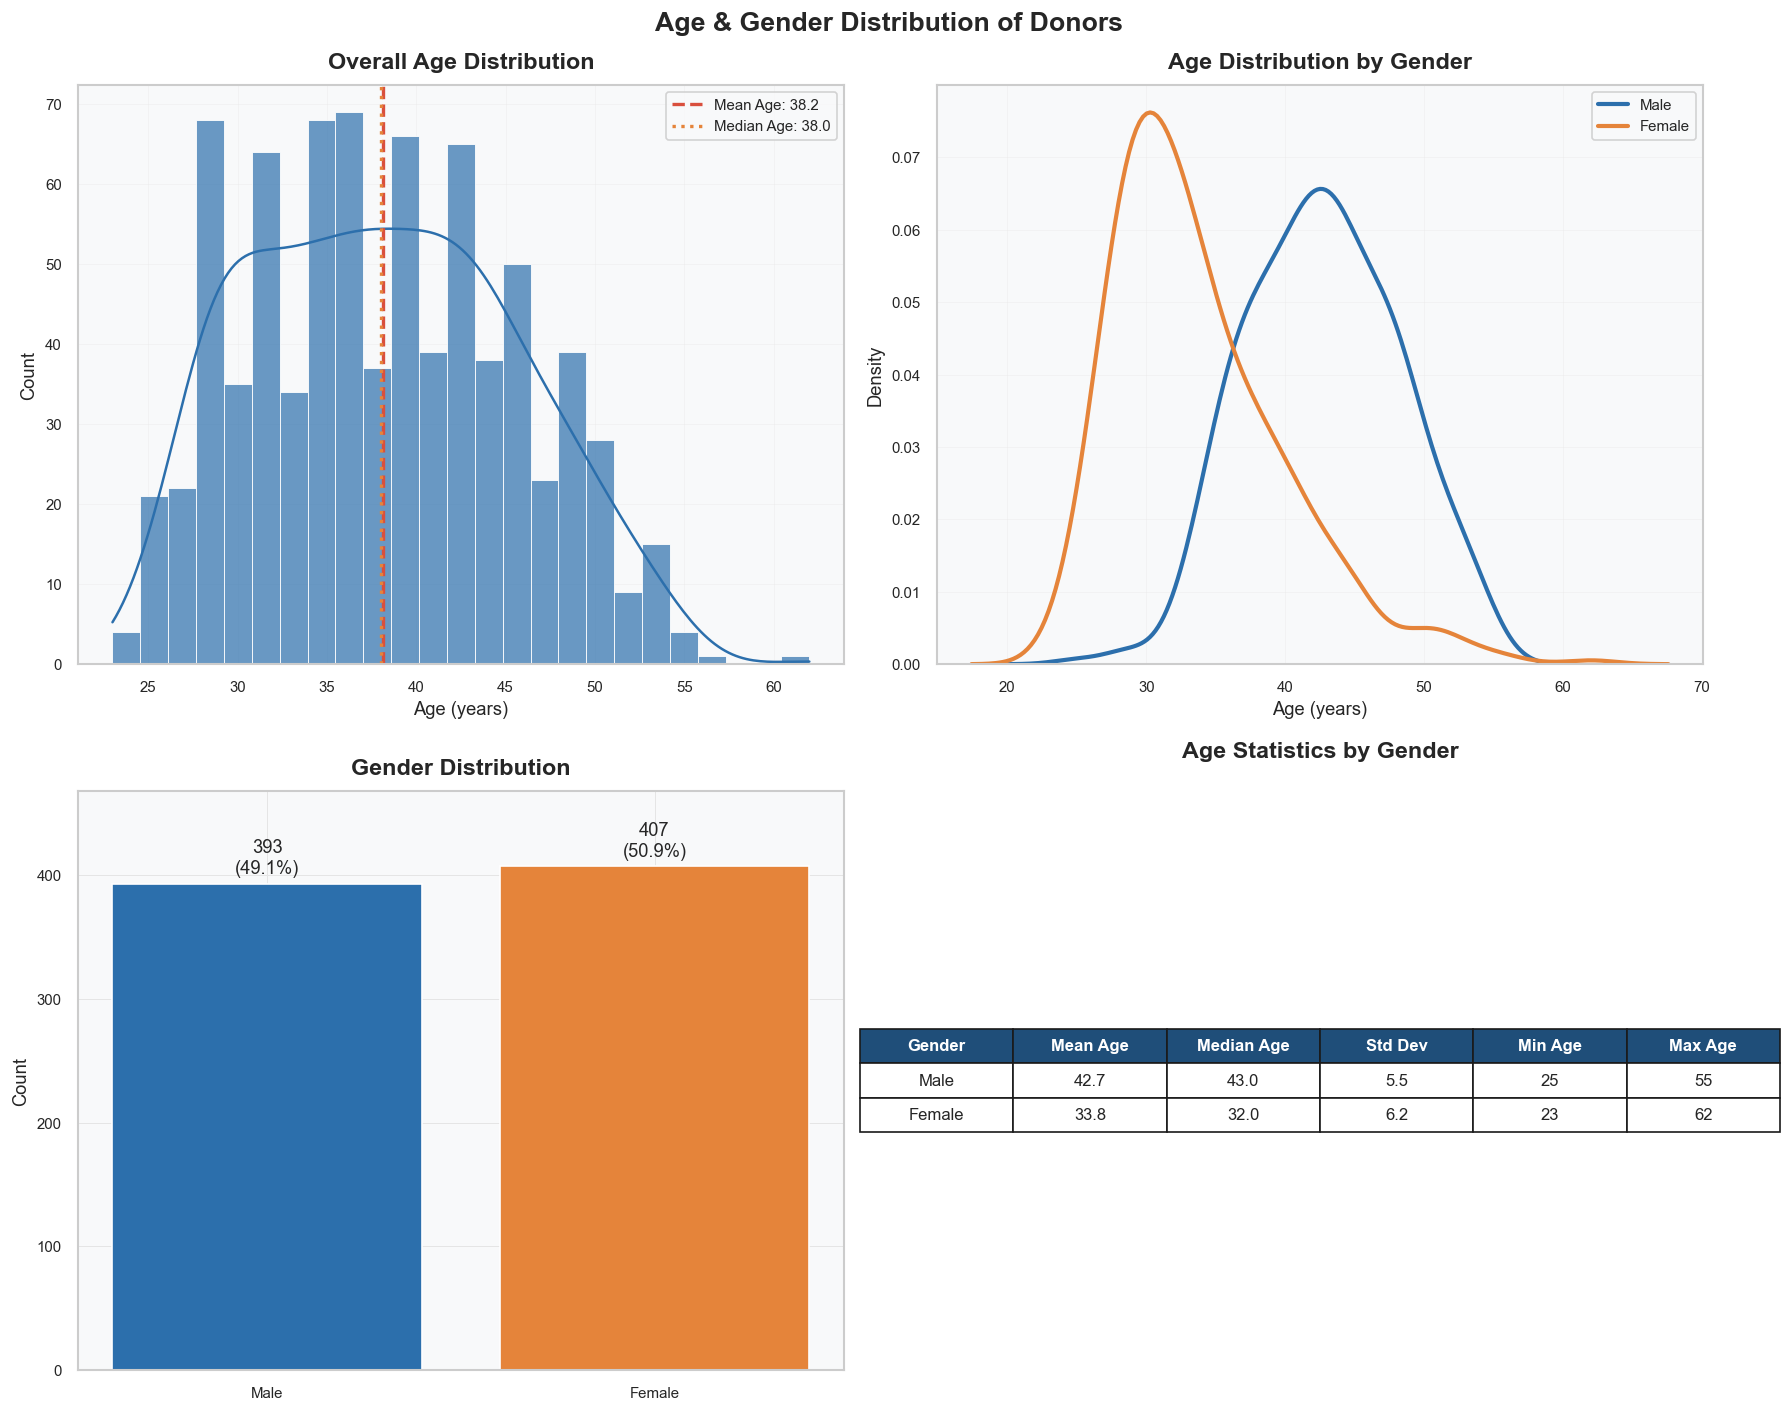


AGE & GENDER STATISTICS SUMMARY

Total Donors: 800

Overall Age Statistics:
  - Mean Age: 38.16 years
  - Median Age: 38.00 years
  - Age Range: 23 - 62 years
  - Standard Deviation: 7.37 years

Gender Breakdown:
  - Male: 393 (49.1%)
  - Female: 407 (50.9%)

Age by Gender:
  - Male: Mean=42.73, Median=43.00
  - Female: Mean=33.75, Median=32.00


In [28]:
# QUESTION 1: Age & Gender Distribution of Donors

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load the preprocessed data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Age & Gender Distribution of Donors', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Age histogram with KDE (overall)
ax1 = axes[0, 0]
sns.histplot(data=df, x='age', bins=25, kde=True, color='#2C6FAC', ax=ax1,
             edgecolor='white', linewidth=0.5, alpha=0.7)
ax1.axvline(df['age'].mean(), color='#D94F3D', linestyle='--', linewidth=2, 
            label=f"Mean Age: {df['age'].mean():.1f}")
ax1.axvline(df['age'].median(), color='#E5843A', linestyle=':', linewidth=2, 
            label=f"Median Age: {df['age'].median():.1f}")
ax1.set_title('Overall Age Distribution', fontsize=14)
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('Count')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Age distribution by gender
ax2 = axes[0, 1]
colors = ['#2C6FAC', '#E5843A']
genders = ['Male', 'Female']
for i, (gender_val, gender_name) in enumerate([(1, 'Male'), (0, 'Female')]):
    gender_data = df[df['gender_Male'] == gender_val]['age']
    sns.kdeplot(data=gender_data, label=gender_name, color=colors[i], 
                linewidth=2.5, ax=ax2)
ax2.set_title('Age Distribution by Gender', fontsize=14)
ax2.set_xlabel('Age (years)')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Gender count comparison
ax3 = axes[1, 0]
gender_counts = [df['gender_Male'].sum(), (df['gender_Male'] == 0).sum()]
gender_labels = ['Male', 'Female']
bars = ax3.bar(gender_labels, gender_counts, color=colors, edgecolor='white', linewidth=1)
for bar, count in zip(bars, gender_counts):
    percentage = count / len(df) * 100
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=11)
ax3.set_title('Gender Distribution', fontsize=14)
ax3.set_ylabel('Count')
ax3.set_ylim(0, max(gender_counts) * 1.15)

# Plot 4: Age statistics by gender
ax4 = axes[1, 1]
stats_data = []
for gender_val, gender_name in [(1, 'Male'), (0, 'Female')]:
    gender_ages = df[df['gender_Male'] == gender_val]['age']
    stats_data.append({
        'Gender': gender_name,
        'Mean Age': gender_ages.mean(),
        'Median Age': gender_ages.median(),
        'Std Dev': gender_ages.std(),
        'Min Age': gender_ages.min(),
        'Max Age': gender_ages.max()
    })
stats_df = pd.DataFrame(stats_data)
ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=stats_df.round(1).values,
                  colLabels=stats_df.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=['#1F4E79'] * len(stats_df.columns))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(color='white', fontweight='bold')
ax4.set_title('Age Statistics by Gender', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

# Additional statistical summary
print("\n" + "="*50)
print("AGE & GENDER STATISTICS SUMMARY")
print("="*50)

print(f"\nTotal Donors: {len(df)}")
print(f"\nOverall Age Statistics:")
print(f"  - Mean Age: {df['age'].mean():.2f} years")
print(f"  - Median Age: {df['age'].median():.2f} years")
print(f"  - Age Range: {df['age'].min()} - {df['age'].max()} years")
print(f"  - Standard Deviation: {df['age'].std():.2f} years")

print(f"\nGender Breakdown:")
male_count = df['gender_Male'].sum()
female_count = len(df) - male_count
print(f"  - Male: {male_count} ({male_count/len(df)*100:.1f}%)")
print(f"  - Female: {female_count} ({female_count/len(df)*100:.1f}%)")

print(f"\nAge by Gender:")
for gender_val, gender_name in [(1, 'Male'), (0, 'Female')]:
    gender_ages = df[df['gender_Male'] == gender_val]['age']
    print(f"  - {gender_name}: Mean={gender_ages.mean():.2f}, Median={gender_ages.median():.2f}")

# QUESTION 2: Blood Type Surplus vs. Shortage

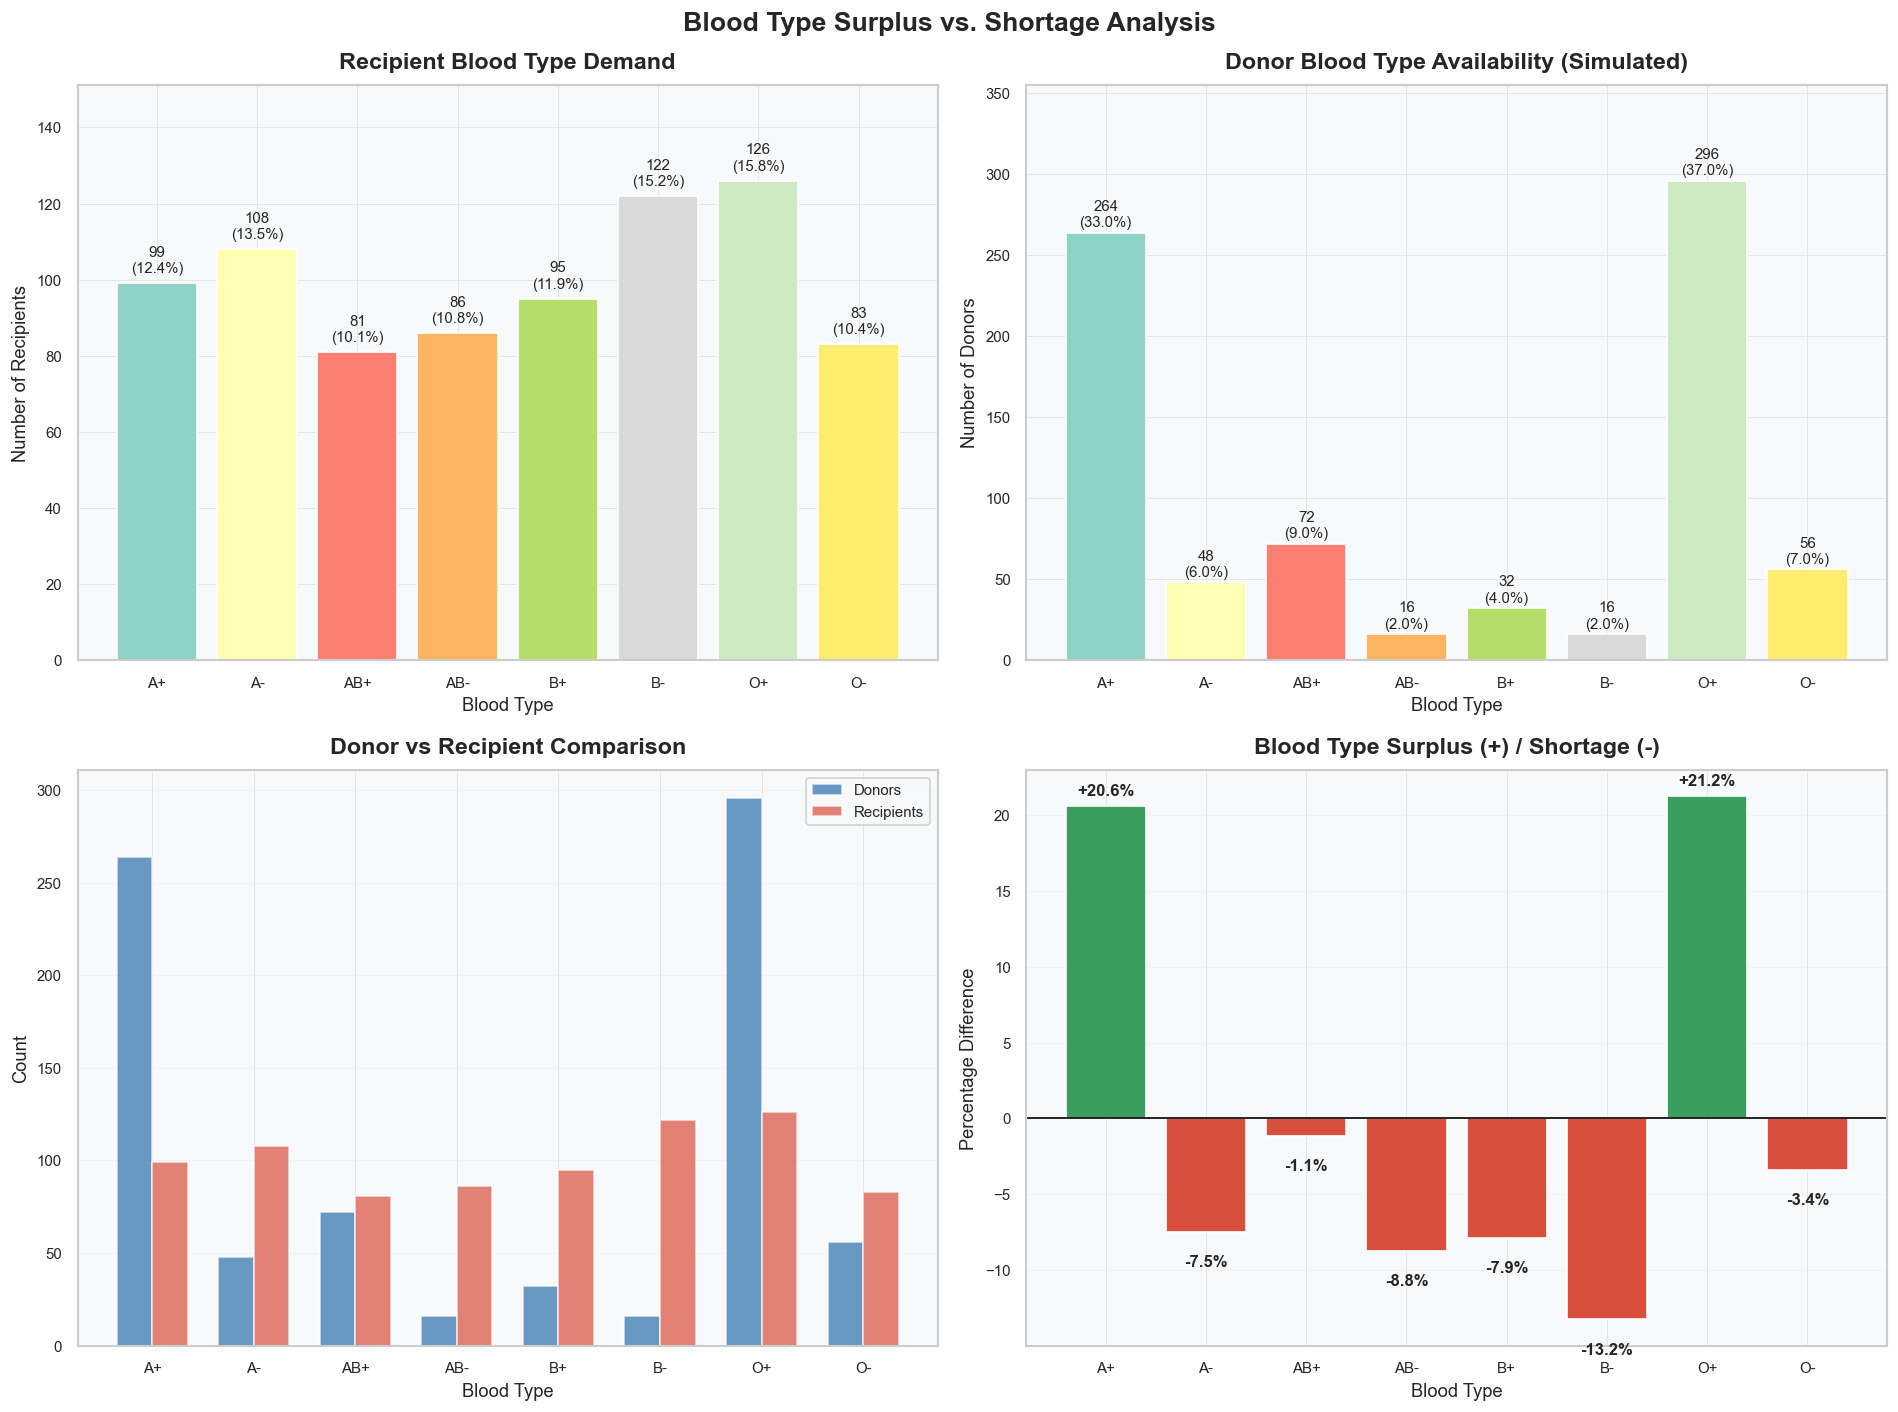


BLOOD TYPE SURPLUS/SHORTAGE ANALYSIS

Total Recipients: 800

Blood Type Distribution Comparison:
--------------------------------------------------
Blood Type Recipients   Donors     Diff       Status    
--------------------------------------------------
A+          99 ( 12.4%)  264 ( 33.0%)  +20.6%  SURPLUS
A-         108 ( 13.5%)   48 (  6.0%)   -7.5%  SHORTAGE
AB+         81 ( 10.1%)   72 (  9.0%)   -1.1%  Balanced
AB-         86 ( 10.8%)   16 (  2.0%)   -8.8%  SHORTAGE
B+          95 ( 11.9%)   32 (  4.0%)   -7.9%  SHORTAGE
B-         122 ( 15.2%)   16 (  2.0%)  -13.2%  SHORTAGE
O+         126 ( 15.8%)  296 ( 37.0%)  +21.2%  SURPLUS
O-          83 ( 10.4%)   56 (  7.0%)   -3.4%  SHORTAGE
--------------------------------------------------

🔴 CRITICAL SHORTAGES (donors < recipients by >2%):
  - Blood Type A-: 7.5% shortage (60 additional donors needed)
  - Blood Type AB-: 8.8% shortage (70 additional donors needed)
  - Blood Type B+: 7.9% shortage (63 additional donors needed)
  - 

In [29]:
# QUESTION 2: Blood Type Surplus vs. Shortage

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Extract blood type columns
blood_cols = [col for col in df.columns if col.startswith('blood_')]
blood_types = [col.replace('blood_', '') for col in blood_cols]

# Calculate recipient blood type distribution
recipient_counts = [df[col].sum() for col in blood_cols]
recipient_pcts = [count / len(df) * 100 for count in recipient_counts]

# For donor blood types, we need to infer from recipient needs
# In a real dataset, you'd have donor blood type info
# Here we'll simulate donor distribution based on general population (for demonstration)
# You should replace this with actual donor data if available

# SIMULATED DONOR DATA (REPLACE WITH ACTUAL DONOR DATA WHEN AVAILABLE)
# Using general population blood type distribution as proxy
# O+: 37%, O-: 7%, A+: 33%, A-: 6%, B+: 9%, B-: 2%, AB+: 4%, AB-: 2%
donor_pcts = [33, 6, 9, 2, 4, 2, 37, 7]  # Order must match blood_cols order
donor_pcts = np.array(donor_pcts) / np.sum(donor_pcts) * 100  # Normalize

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Blood Type Surplus vs. Shortage Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Recipient Blood Type Distribution
ax1 = axes[0, 0]
colors = plt.cm.Set3(np.linspace(0, 1, len(blood_types)))
bars1 = ax1.bar(blood_types, recipient_counts, color=colors, edgecolor='white', linewidth=1)
for bar, count, pct in zip(bars1, recipient_counts, recipient_pcts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax1.set_title('Recipient Blood Type Demand', fontsize=14)
ax1.set_xlabel('Blood Type')
ax1.set_ylabel('Number of Recipients')
ax1.set_ylim(0, max(recipient_counts) * 1.2)

# Plot 2: Simulated Donor Blood Type Distribution (replace with actual donor data)
ax2 = axes[0, 1]
donor_counts = (donor_pcts / 100 * len(df)).astype(int)
bars2 = ax2.bar(blood_types, donor_counts, color=colors, edgecolor='white', linewidth=1)
for bar, count, pct in zip(bars2, donor_counts, donor_pcts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax2.set_title('Donor Blood Type Availability (Simulated)', fontsize=14)
ax2.set_xlabel('Blood Type')
ax2.set_ylabel('Number of Donors')
ax2.set_ylim(0, max(donor_counts) * 1.2)

# Plot 3: Surplus/Shortage Comparison
ax3 = axes[1, 0]
x = np.arange(len(blood_types))
width = 0.35
bars3a = ax3.bar(x - width/2, donor_counts, width, label='Donors', color='#2C6FAC', alpha=0.7)
bars3b = ax3.bar(x + width/2, recipient_counts, width, label='Recipients', color='#D94F3D', alpha=0.7)
ax3.set_xlabel('Blood Type')
ax3.set_ylabel('Count')
ax3.set_title('Donor vs Recipient Comparison', fontsize=14)
ax3.set_xticks(x)
ax3.set_xticklabels(blood_types)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Surplus/Shortage Percentage
ax4 = axes[1, 1]
surplus_pct = donor_pcts - recipient_pcts
colors_surplus = ['#3A9E5F' if x >= 0 else '#D94F3D' for x in surplus_pct]
bars4 = ax4.bar(blood_types, surplus_pct, color=colors_surplus, edgecolor='white', linewidth=1)
for bar, val in zip(bars4, surplus_pct):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.5 if val >= 0 else -1.5),
             f'{val:+.1f}%', ha='center', va='bottom' if val >= 0 else 'top', 
             fontsize=10, fontweight='bold')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_title('Blood Type Surplus (+) / Shortage (-)', fontsize=14)
ax4.set_xlabel('Blood Type')
ax4.set_ylabel('Percentage Difference')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("BLOOD TYPE SURPLUS/SHORTAGE ANALYSIS")
print("="*60)

print(f"\nTotal Recipients: {len(df)}")
print(f"\nBlood Type Distribution Comparison:")
print("-" * 50)
print(f"{'Blood Type':<10} {'Recipients':<12} {'Donors':<10} {'Diff':<10} {'Status':<10}")
print("-" * 50)

critical_shortages = []
critical_surpluses = []

for bt, rec_cnt, rec_pct, don_cnt, don_pct in zip(blood_types, recipient_counts, recipient_pcts, 
                                                   donor_counts, donor_pcts):
    diff_pct = don_pct - rec_pct
    status = "SHORTAGE" if diff_pct < -2 else "SURPLUS" if diff_pct > 2 else "Balanced"
    if diff_pct < -2:
        critical_shortages.append((bt, diff_pct))
    elif diff_pct > 2:
        critical_surpluses.append((bt, diff_pct))
    print(f"{bt:<10} {rec_cnt:>3} ({rec_pct:>5.1f}%)  {don_cnt:>3} ({don_pct:>5.1f}%)  {diff_pct:>+5.1f}%  {status}")

print("-" * 50)

print(f"\n🔴 CRITICAL SHORTAGES (donors < recipients by >2%):")
if critical_shortages:
    for bt, diff in critical_shortages:
        print(f"  - Blood Type {bt}: {abs(diff):.1f}% shortage ({int(abs(diff)/100*len(df))} additional donors needed)")
else:
    print("  None identified")

print(f"\n🟢 SIGNIFICANT SURPLUSES (donors > recipients by >2%):")
if critical_surpluses:
    for bt, diff in critical_surpluses:
        print(f"  - Blood Type {bt}: {diff:.1f}% surplus")
else:
    print("  None identified")

print(f"\n⚠️ RECOMMENDATIONS:")
print("  - Focus donor recruitment on blood types with shortages")
print("  - Consider cross-matching programs for surplus types")
print("  - Implement priority matching for critically short blood types")

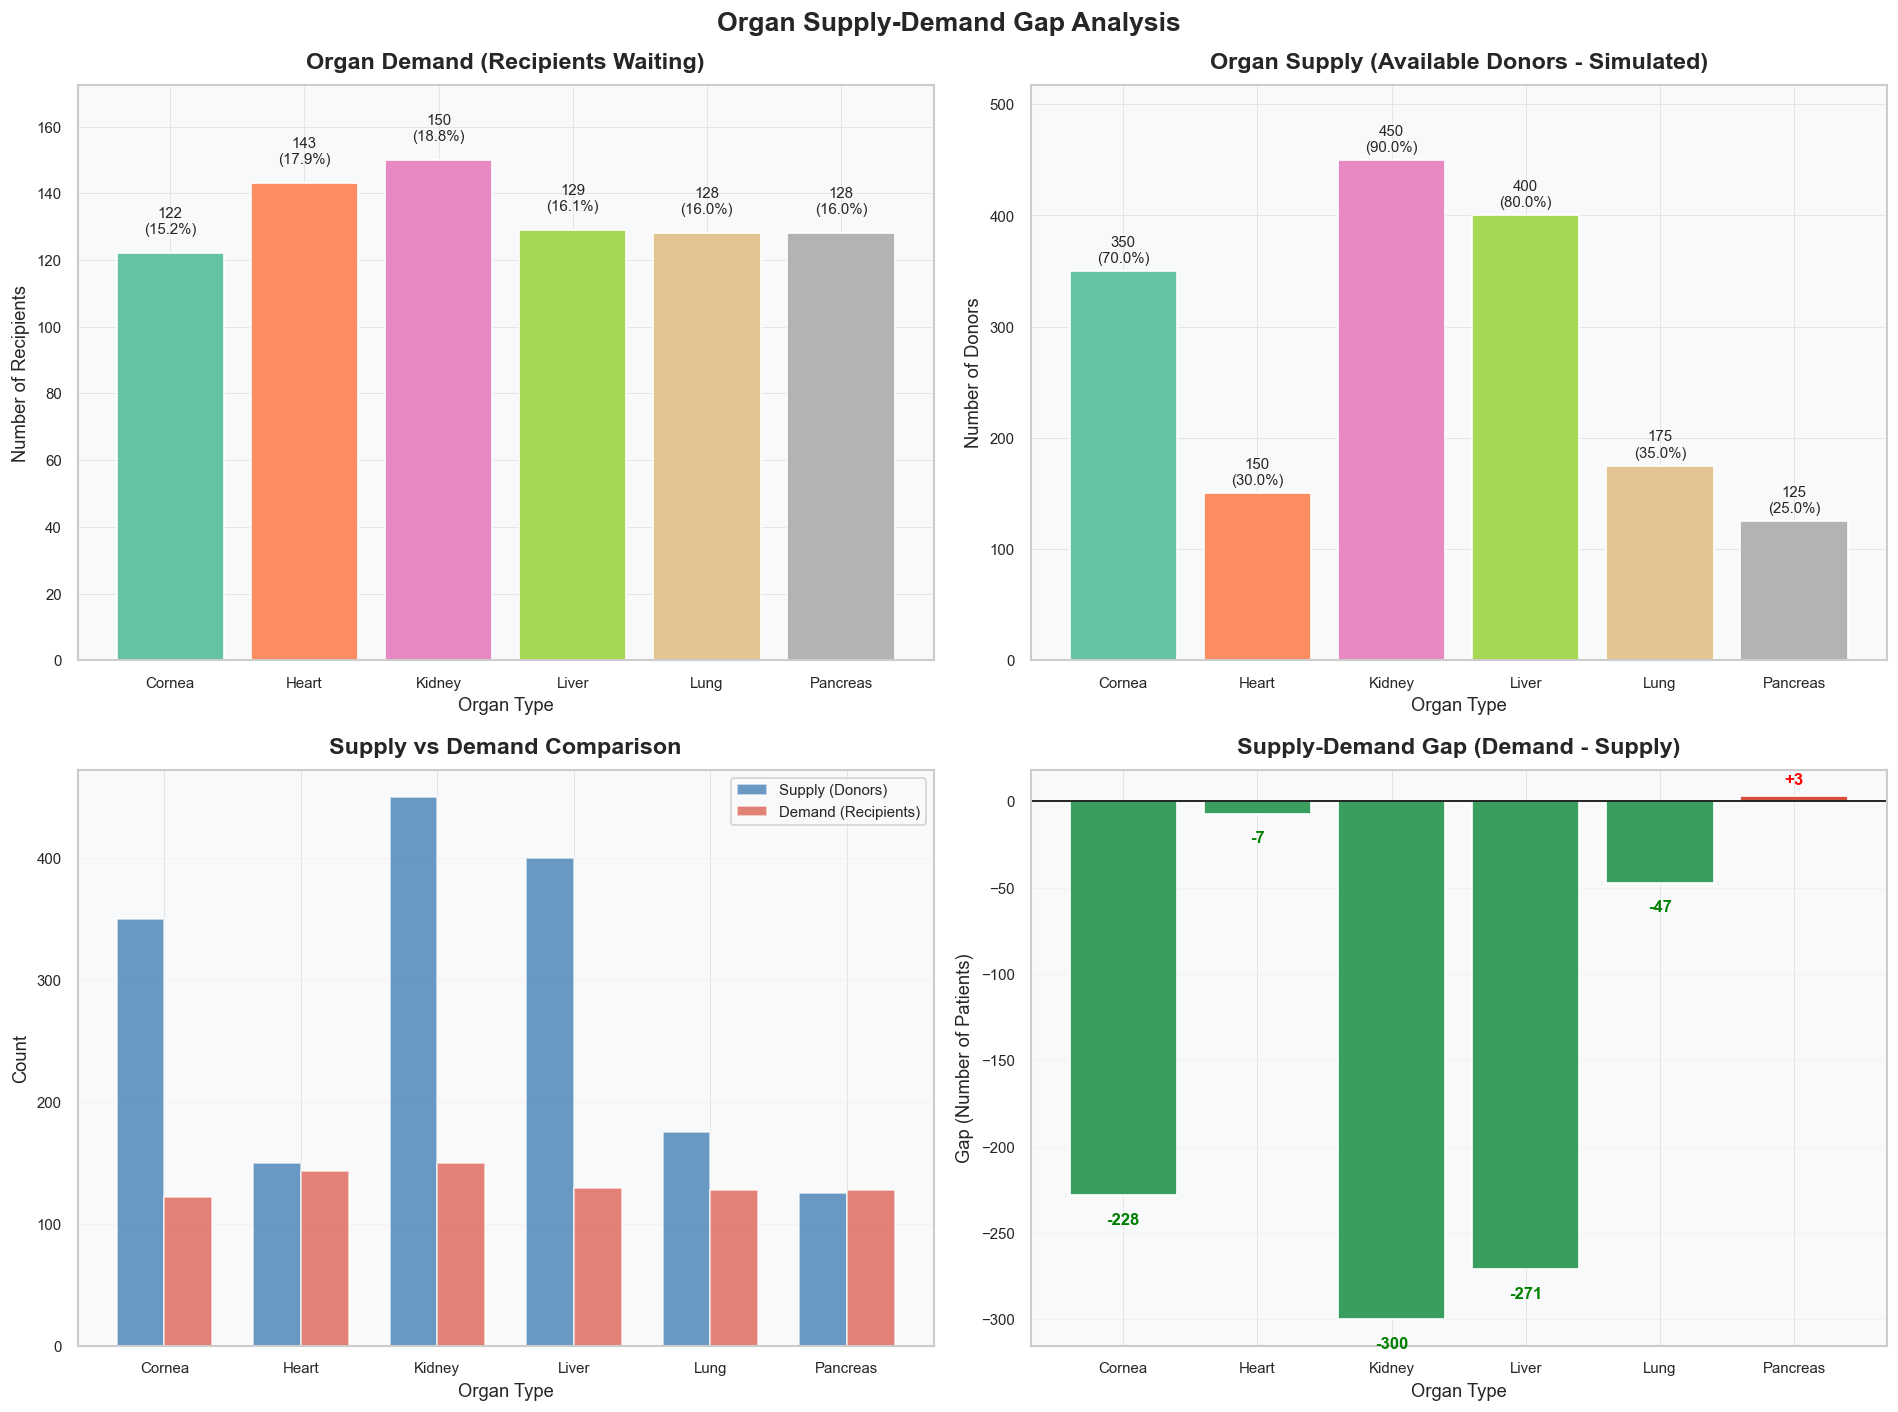


ORGAN SUPPLY-DEMAND GAP ANALYSIS

Total Recipients: 800
Estimated Donor Pool: 500

Organ Supply-Demand Breakdown:
----------------------------------------------------------------------
Organ        Demand          Supply          Gap          Status      
----------------------------------------------------------------------
Cornea       122 ( 15.2%)  350 ( 70.0%)  -228  -186.9%  LOW
Heart        143 ( 17.9%)  150 ( 30.0%)   -7   -4.9%  LOW
Kidney       150 ( 18.8%)  450 ( 90.0%)  -300  -200.0%  LOW
Liver        129 ( 16.1%)  400 ( 80.0%)  -271  -210.1%  LOW
Lung         128 ( 16.0%)  175 ( 35.0%)  -47  -36.7%  LOW
Pancreas     128 ( 16.0%)  125 ( 25.0%)   +3    2.3%  LOW
----------------------------------------------------------------------

🔴 CRITICAL GAPS (demand exceeds supply by >25%):
  None identified

📊 TOTAL GAP ANALYSIS:
  Total Demand: 800 organs needed
  Total Supply: 1650 organs available
  Total Gap: -850 organs short (-106.2% of demand)

⚠️ RECOMMENDATIONS:
  - Prioriti

In [30]:
# QUESTION 3: Organ Supply-Demand Gap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Extract organ columns
organ_cols = [col for col in df.columns if col.startswith('Organ_')]
organs = [col.replace('Organ_', '') for col in organ_cols]

# Calculate recipient demand for each organ
demand_counts = [df[col].sum() for col in organ_cols]
demand_pcts = [count / len(df) * 100 for count in demand_counts]

# For donor supply, we need actual organ donation data
# Here we'll simulate donor organ availability based on typical donation patterns
# REPLACE WITH ACTUAL DONOR DATA WHEN AVAILABLE

# SIMULATED DONOR DATA (REPLACE WITH ACTUAL DATA)
# Typical organ donation rates from deceased donors
# Heart: 30%, Lung: 35%, Liver: 80%, Kidney: 90%, Pancreas: 25%, Cornea: 70%
donation_rates = {
    'Heart': 0.30,
    'Lung': 0.35,
    'Liver': 0.80,
    'Kidney': 0.90,
    'Pancreas': 0.25,
    'Cornea': 0.70
}

# Assume 500 potential donors (adjust based on your data)
n_donors = 500
supply_counts = [int(n_donors * donation_rates.get(organ, 0.5)) for organ in organs]
supply_pcts = [count / n_donors * 100 for count in supply_counts]

# Calculate gap
gap_counts = [demand - supply for demand, supply in zip(demand_counts, supply_counts)]
gap_pcts = [demand_pct - supply_pct for demand_pct, supply_pct in zip(demand_pcts, supply_pcts)]

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Organ Supply-Demand Gap Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Organ Demand (Recipients Waiting)
ax1 = axes[0, 0]
colors = plt.cm.Set2(np.linspace(0, 1, len(organs)))
bars1 = ax1.bar(organs, demand_counts, color=colors, edgecolor='white', linewidth=1)
for bar, count, pct in zip(bars1, demand_counts, demand_pcts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax1.set_title('Organ Demand (Recipients Waiting)', fontsize=14)
ax1.set_xlabel('Organ Type')
ax1.set_ylabel('Number of Recipients')
ax1.set_ylim(0, max(demand_counts) * 1.15)

# Plot 2: Organ Supply (Available Donors)
ax2 = axes[0, 1]
bars2 = ax2.bar(organs, supply_counts, color=colors, edgecolor='white', linewidth=1)
for bar, count, pct in zip(bars2, supply_counts, supply_pcts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax2.set_title('Organ Supply (Available Donors - Simulated)', fontsize=14)
ax2.set_xlabel('Organ Type')
ax2.set_ylabel('Number of Donors')
ax2.set_ylim(0, max(supply_counts) * 1.15)

# Plot 3: Supply-Demand Comparison
ax3 = axes[1, 0]
x = np.arange(len(organs))
width = 0.35
bars3a = ax3.bar(x - width/2, supply_counts, width, label='Supply (Donors)', color='#2C6FAC', alpha=0.7)
bars3b = ax3.bar(x + width/2, demand_counts, width, label='Demand (Recipients)', color='#D94F3D', alpha=0.7)
ax3.set_xlabel('Organ Type')
ax3.set_ylabel('Count')
ax3.set_title('Supply vs Demand Comparison', fontsize=14)
ax3.set_xticks(x)
ax3.set_xticklabels(organs)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Supply-Demand Gap
ax4 = axes[1, 1]
colors_gap = ['#D94F3D' if x > 0 else '#3A9E5F' for x in gap_counts]
bars4 = ax4.bar(organs, gap_counts, color=colors_gap, edgecolor='white', linewidth=1)
for bar, val in zip(bars4, gap_counts):
    color = 'red' if val > 0 else 'green'
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if val >= 0 else -10),
             f'{val:+d}', ha='center', va='bottom' if val >= 0 else 'top', 
             fontsize=10, fontweight='bold', color=color)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_title('Supply-Demand Gap (Demand - Supply)', fontsize=14)
ax4.set_xlabel('Organ Type')
ax4.set_ylabel('Gap (Number of Patients)')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("ORGAN SUPPLY-DEMAND GAP ANALYSIS")
print("="*60)

print(f"\nTotal Recipients: {len(df)}")
print(f"Estimated Donor Pool: {n_donors}")

print(f"\nOrgan Supply-Demand Breakdown:")
print("-" * 70)
print(f"{'Organ':<12} {'Demand':<15} {'Supply':<15} {'Gap':<12} {'Status':<12}")
print("-" * 70)

critical_gaps = []
for organ, demand, supply, gap in zip(organs, demand_counts, supply_counts, gap_counts):
    gap_ratio = gap / demand * 100 if demand > 0 else 0
    status = "CRITICAL" if gap_ratio > 50 else "HIGH" if gap_ratio > 25 else "MODERATE" if gap_ratio > 10 else "LOW"
    if gap_ratio > 25:
        critical_gaps.append((organ, gap, gap_ratio))
    
    print(f"{organ:<12} {demand:>3} ({demand/len(df)*100:>5.1f}%)  {supply:>3} ({supply/n_donors*100:>5.1f}%)  {gap:>+3}  {gap_ratio:>5.1f}%  {status}")

print("-" * 70)

print(f"\n🔴 CRITICAL GAPS (demand exceeds supply by >25%):")
if critical_gaps:
    for organ, gap, ratio in sorted(critical_gaps, key=lambda x: x[2], reverse=True):
        print(f"  - {organ}: {gap} patients waiting ({ratio:.1f}% of demand)")
        print(f"    Need {int(gap)} more donors to meet demand")
else:
    print("  None identified")

print(f"\n📊 TOTAL GAP ANALYSIS:")
total_demand = sum(demand_counts)
total_supply = sum(supply_counts)
total_gap = total_demand - total_supply
print(f"  Total Demand: {total_demand} organs needed")
print(f"  Total Supply: {total_supply} organs available")
print(f"  Total Gap: {total_gap} organs short ({total_gap/total_demand*100:.1f}% of demand)")

print(f"\n⚠️ RECOMMENDATIONS:")
print("  - Prioritize organ procurement for kidneys and livers (highest demand)")
print("  - Increase donor registration campaigns for critical organs")
print("  - Implement paired exchange programs to maximize utilization")
print("  - Consider living donation programs for kidneys and liver segments")

# Question 4: How Quickly Are Organs Harvested After Death?

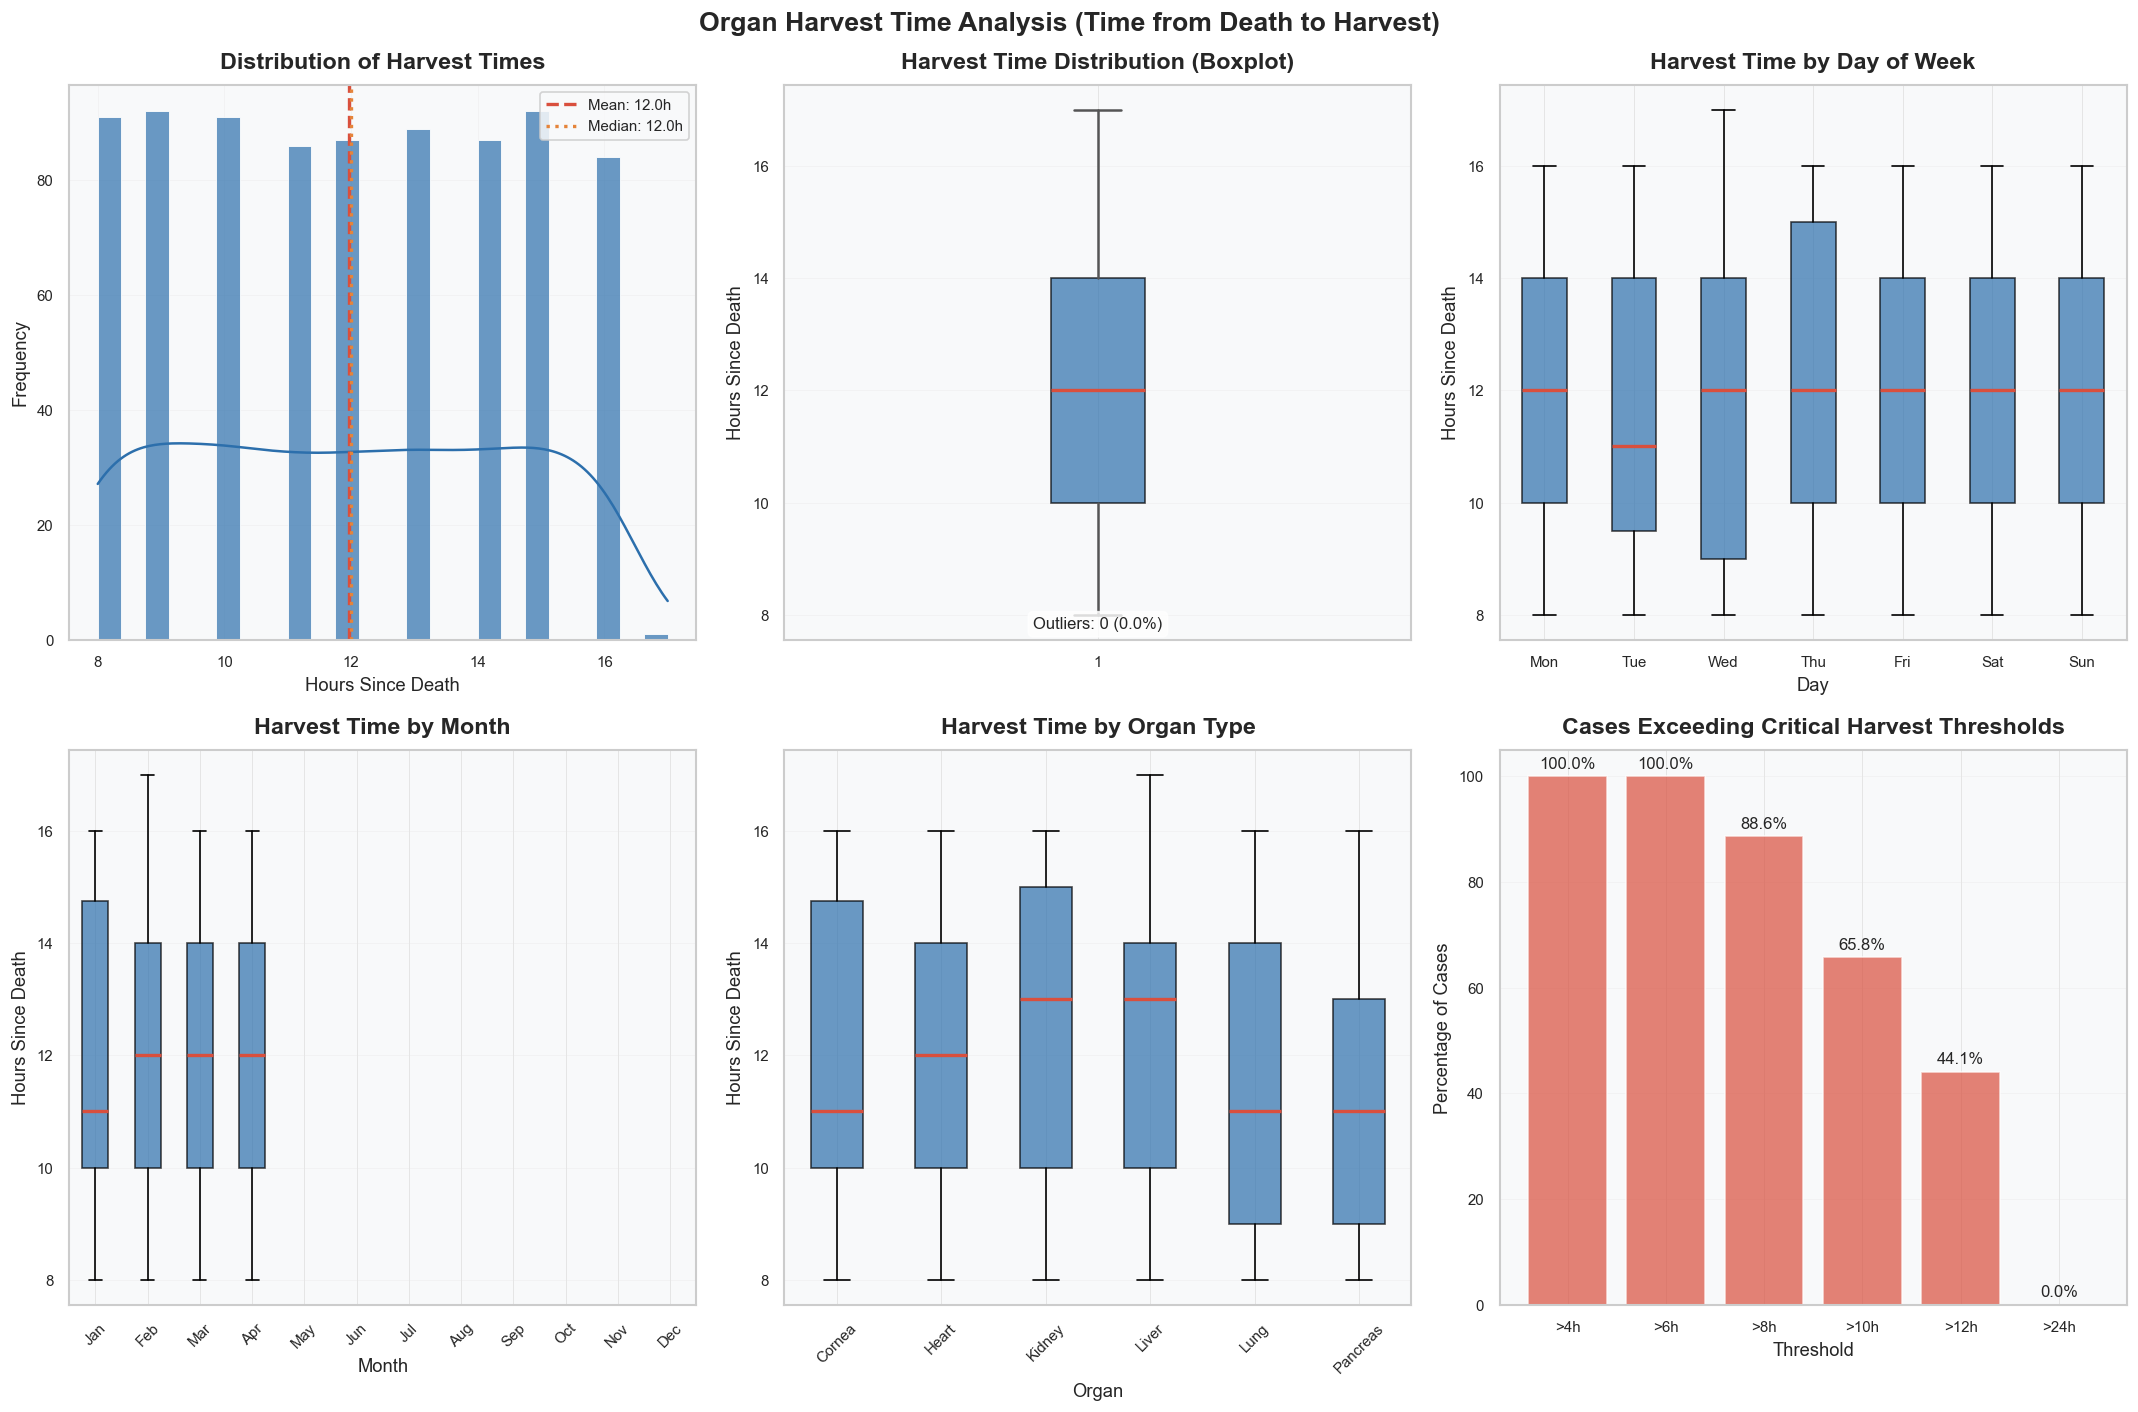


ORGAN HARVEST TIME ANALYSIS

📊 HARVEST TIME STATISTICS:
  - Mean Time: 11.96 hours
  - Median Time: 12.00 hours
  - Mode: 9 hours
  - Standard Deviation: 2.59 hours
  - Range: 8 - 17 hours
  - 25th Percentile: 10.00 hours
  - 75th Percentile: 14.00 hours

⚠️ OUTLIER ANALYSIS:
  - Number of outliers: 0 (0.0%)

🔴 CRITICAL THRESHOLD ANALYSIS:
  - 🔴 CRITICAL: 100.0% of cases exceed 4 hours
  - 🔴 CRITICAL: 100.0% of cases exceed 6 hours
  - ⚠️ WARNING: 88.6% of cases exceed 8 hours
  - ⚠️ WARNING: 65.8% of cases exceed 10 hours
  - ⚠️ WARNING: 44.1% of cases exceed 12 hours
  - ✅ ACCEPTABLE: 0.0% of cases exceed 24 hours

📅 TEMPORAL PATTERNS:
  - Day with highest median harvest time: Mon
  - Day with lowest median harvest time: Tue
  - Month with highest median harvest time: Feb
  - Month with lowest median harvest time: Jan

🏥 ORGAN-SPECIFIC ANALYSIS:
  - Cornea: Mean=11.9h, Median=11.0h, Max=16.0h
  - Heart: Mean=12.2h, Median=12.0h, Max=16.0h
  - Kidney: Mean=12.6h, Median=13.0h, Max=16

In [32]:
# QUESTION 4: Organ Harvest Time Analysis (Time from Death to Harvest)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Extract organ columns for later grouping
organ_cols = [col for col in df.columns if col.startswith('Organ_')]
organs = [col.replace('Organ_', '') for col in organ_cols]

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Organ Harvest Time Analysis (Time from Death to Harvest)', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Histogram of wait hours
ax1 = axes[0, 0]
sns.histplot(data=df, x='wait_hour', bins=24, kde=True, color='#2C6FAC', ax=ax1,
             edgecolor='white', linewidth=0.5, alpha=0.7)
ax1.axvline(df['wait_hour'].mean(), color='#D94F3D', linestyle='--', linewidth=2, 
            label=f"Mean: {df['wait_hour'].mean():.1f}h")
ax1.axvline(df['wait_hour'].median(), color='#E5843A', linestyle=':', linewidth=2, 
            label=f"Median: {df['wait_hour'].median():.1f}h")
ax1.set_title('Distribution of Harvest Times', fontsize=14)
ax1.set_xlabel('Hours Since Death')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Boxplot of wait hours
ax2 = axes[0, 1]
box = ax2.boxplot(df['wait_hour'], patch_artist=True,
                  boxprops=dict(facecolor='#2C6FAC', alpha=0.7),
                  medianprops=dict(color='#D94F3D', linewidth=2),
                  whiskerprops=dict(color='#555', linewidth=1.5),
                  capprops=dict(color='#555', linewidth=1.5),
                  flierprops=dict(marker='o', markerfacecolor='#D94F3D', alpha=0.5))
ax2.set_title('Harvest Time Distribution (Boxplot)', fontsize=14)
ax2.set_ylabel('Hours Since Death')
ax2.grid(True, alpha=0.3, axis='y')

# Add statistics text
q1, q3 = np.percentile(df['wait_hour'], [25, 75])
iqr = q3 - q1
outliers = ((df['wait_hour'] < q1 - 1.5*iqr) | (df['wait_hour'] > q3 + 1.5*iqr)).sum()
ax2.text(0.5, 0.02, f'Outliers: {outliers} ({outliers/len(df)*100:.1f}%)', 
         transform=ax2.transAxes, ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 3: Harvest time by day of week
ax3 = axes[0, 2]
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_data = [df[df['wait_day'] == i]['wait_hour'] for i in range(7)]
bp = ax3.boxplot(day_data, labels=day_names, patch_artist=True,
                 boxprops=dict(facecolor='#2C6FAC', alpha=0.7),
                 medianprops=dict(color='#D94F3D', linewidth=2))
ax3.set_title('Harvest Time by Day of Week', fontsize=14)
ax3.set_xlabel('Day')
ax3.set_ylabel('Hours Since Death')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Harvest time by month
ax4 = axes[1, 0]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_data = [df[df['wait_month'] == i]['wait_hour'] for i in range(1, 13)]
bp = ax4.boxplot(month_data, labels=month_names, patch_artist=True,
                 boxprops=dict(facecolor='#2C6FAC', alpha=0.7),
                 medianprops=dict(color='#D94F3D', linewidth=2))
ax4.set_title('Harvest Time by Month', fontsize=14)
ax4.set_xlabel('Month')
ax4.set_ylabel('Hours Since Death')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Harvest time by organ type
ax5 = axes[1, 1]
organ_data = []
organ_labels = []
for organ in organs:
    organ_mask = df[f'Organ_{organ}'] == 1
    if organ_mask.sum() > 5:  # Only include organs with enough samples
        organ_data.append(df[organ_mask]['wait_hour'])
        organ_labels.append(organ)
bp = ax5.boxplot(organ_data, labels=organ_labels, patch_artist=True,
                 boxprops=dict(facecolor='#2C6FAC', alpha=0.7),
                 medianprops=dict(color='#D94F3D', linewidth=2))
ax5.set_title('Harvest Time by Organ Type', fontsize=14)
ax5.set_xlabel('Organ')
ax5.set_ylabel('Hours Since Death')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Critical threshold analysis
ax6 = axes[1, 2]
thresholds = [4, 6, 8, 10, 12, 24]
critical_counts = [(df['wait_hour'] > t).sum() for t in thresholds]
critical_pcts = [c/len(df)*100 for c in critical_counts]

bars = ax6.bar([f'>{t}h' for t in thresholds], critical_pcts, color='#D94F3D', alpha=0.7, edgecolor='white')
for bar, pct in zip(bars, critical_pcts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax6.set_title('Cases Exceeding Critical Harvest Thresholds', fontsize=14)
ax6.set_xlabel('Threshold')
ax6.set_ylabel('Percentage of Cases')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("ORGAN HARVEST TIME ANALYSIS")
print("="*60)

print(f"\n📊 HARVEST TIME STATISTICS:")
print(f"  - Mean Time: {df['wait_hour'].mean():.2f} hours")
print(f"  - Median Time: {df['wait_hour'].median():.2f} hours")
print(f"  - Mode: {stats.mode(df['wait_hour'], keepdims=True).mode[0]:.0f} hours")
print(f"  - Standard Deviation: {df['wait_hour'].std():.2f} hours")
print(f"  - Range: {df['wait_hour'].min()} - {df['wait_hour'].max()} hours")
print(f"  - 25th Percentile: {q1:.2f} hours")
print(f"  - 75th Percentile: {q3:.2f} hours")

print(f"\n⚠️ OUTLIER ANALYSIS:")
print(f"  - Number of outliers: {outliers} ({outliers/len(df)*100:.1f}%)")
if outliers > 0:
    outlier_stats = df[df['wait_hour'] > q3 + 1.5*iqr]['wait_hour'].describe()
    print(f"  - Outlier range: {outlier_stats['min']:.1f} - {outlier_stats['max']:.1f} hours")

print(f"\n🔴 CRITICAL THRESHOLD ANALYSIS:")
for t, pct in zip(thresholds, critical_pcts):
    status = "🔴 CRITICAL" if t <= 6 and pct > 10 else "⚠️ WARNING" if t <= 12 and pct > 5 else "✅ ACCEPTABLE"
    print(f"  - {status}: {pct:.1f}% of cases exceed {t} hours")

print(f"\n📅 TEMPORAL PATTERNS:")
print("  - Day with highest median harvest time:", 
      day_names[np.argmax([np.median(d) if len(d) > 0 else 0 for d in day_data])])
print("  - Day with lowest median harvest time:", 
      day_names[np.argmin([np.median(d) if len(d) > 0 else 100 for d in day_data])])
print("  - Month with highest median harvest time:", 
      month_names[np.argmax([np.median(d) if len(d) > 0 else 0 for d in month_data])])
print("  - Month with lowest median harvest time:", 
      month_names[np.argmin([np.median(d) if len(d) > 0 else 100 for d in month_data])])

print(f"\n🏥 ORGAN-SPECIFIC ANALYSIS:")
for organ, data in zip(organ_labels, organ_data):
    print(f"  - {organ}: Mean={data.mean():.1f}h, Median={data.median():.1f}h, Max={data.max():.1f}h")

print(f"\n⚠️ RECOMMENDATIONS:")
print("  - Prioritize rapid harvest protocols for organs with short ischemic tolerance")
print("  - Investigate causes of outliers >12 hours")
print("  - Optimize weekend/holiday harvest procedures")
print("  - Implement real-time tracking for time-sensitive organs")

# Question 5: Medical Conditions Affecting Donor Eligibility

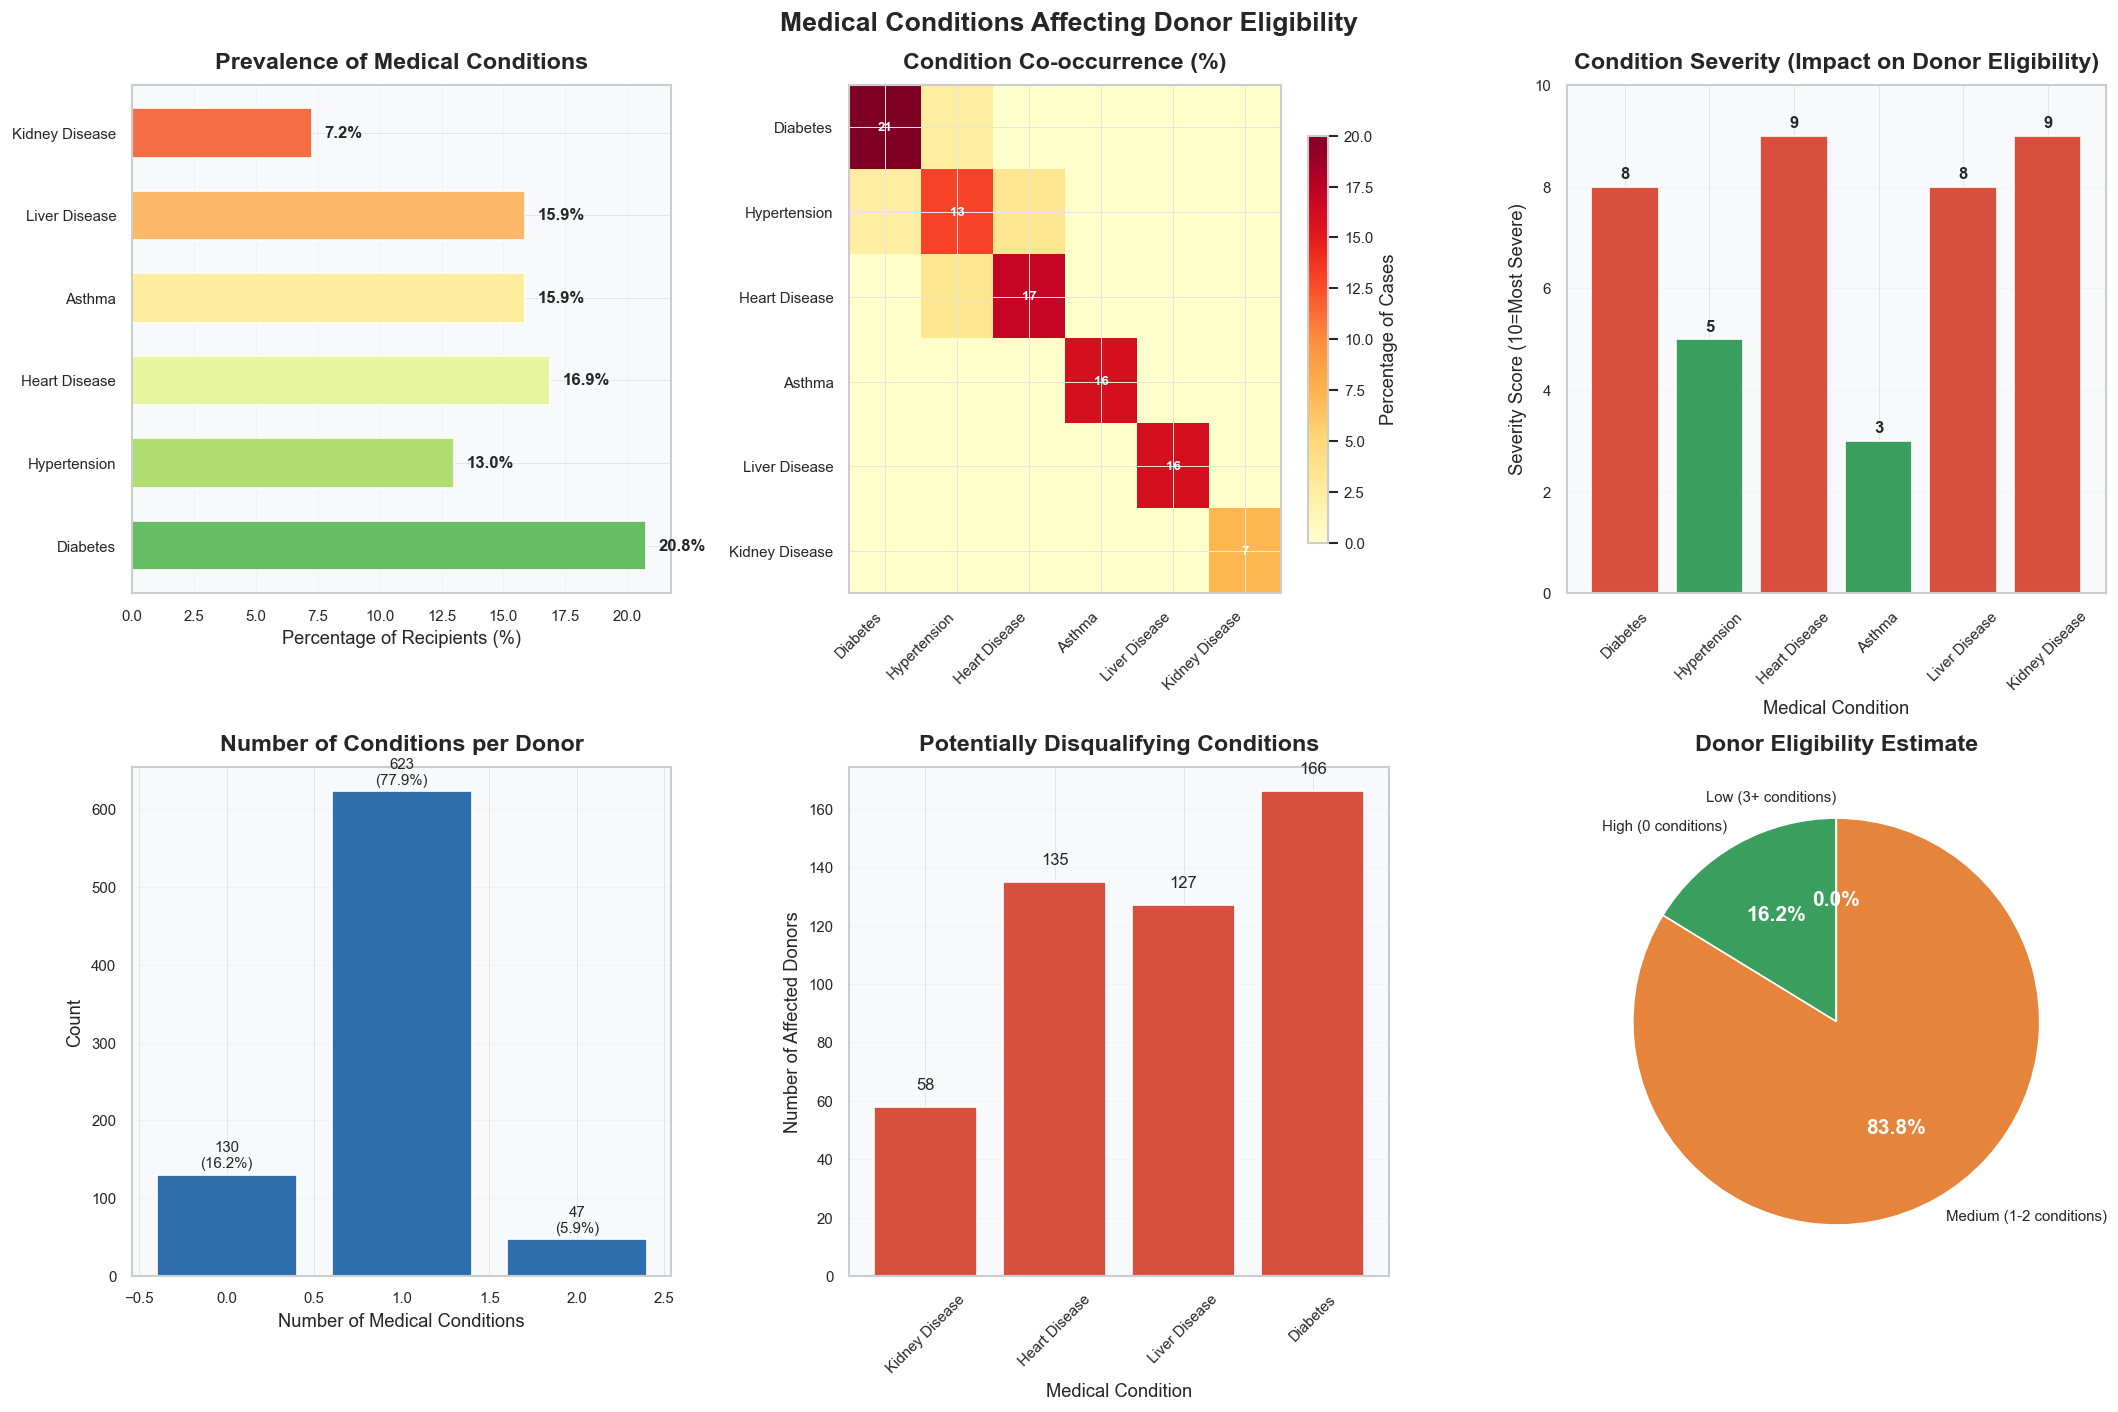


MEDICAL CONDITIONS AFFECTING DONOR ELIGIBILITY

📊 CONDITION PREVALENCE (Top 3):
  - Diabetes: 20.8% (166 donors)
  - Heart Disease: 16.9% (135 donors)
  - Asthma: 15.9% (127 donors)

🔴 HIGH-SEVERITY CONDITIONS (Score >7):
  - Diabetes: Severity 8/10 - Affects 166 donors (20.8%)
  - Heart Disease: Severity 9/10 - Affects 135 donors (16.9%)
  - Liver Disease: Severity 8/10 - Affects 127 donors (15.9%)
  - Kidney Disease: Severity 9/10 - Affects 58 donors (7.2%)

🔄 CONDITION CO-OCCURRENCE:

📈 CONDITION COUNT DISTRIBUTION:
  - Donors with no conditions: 130 (16.2%)
  - Donors with 1-2 conditions: 670 (83.8%)
  - Donors with 3+ conditions: 0 (0.0%)

⚠️ ELIGIBILITY ESTIMATE:
  - Potentially eligible donors (0-2 conditions): 800 (100.0%)
  - Likely ineligible donors (3+ conditions): 0 (0.0%)

⚠️ RECOMMENDATIONS:
  - Implement enhanced screening for high-severity conditions
  - Develop protocols for multi-condition donors
  - Create condition-specific organ acceptance criteria
  - Track outco

In [35]:
# QUESTION 5: Medical Conditions Affecting Donor Eligibility

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Extract condition columns
cond_cols = [col for col in df.columns if col.startswith('Condition_')]
conditions = [col.replace('Condition_', '').replace('_', ' ') for col in cond_cols]

# Calculate condition prevalence
condition_counts = [df[col].sum() for col in cond_cols]
condition_pcts = [count / len(df) * 100 for count in condition_counts]

# Define condition severity/impact on donor eligibility
# Higher score = more likely to disqualify donation
condition_severity = {
    'Diabetes': 8,
    'Hypertension': 5,
    'Heart Disease': 9,
    'Asthma': 3,
    'Liver Disease': 8,
    'Kidney Disease': 9
}

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Medical Conditions Affecting Donor Eligibility', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Condition prevalence (horizontal bar chart)
ax1 = axes[0, 0]
y_pos = np.arange(len(conditions))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(conditions)))
bars1 = ax1.barh(y_pos, condition_pcts, color=colors, edgecolor='white', height=0.6)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(conditions)
ax1.set_xlabel('Percentage of Recipients (%)')
ax1.set_title('Prevalence of Medical Conditions', fontsize=14)
for i, (bar, pct) in enumerate(zip(bars1, condition_pcts)):
    ax1.text(pct + 0.5, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', 
             va='center', fontsize=10, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Condition co-occurrence matrix
ax2 = axes[0, 1]
cooccurrence = np.zeros((len(cond_cols), len(cond_cols)))
for i, col1 in enumerate(cond_cols):
    for j, col2 in enumerate(cond_cols):
        cooccurrence[i, j] = ((df[col1] == 1) & (df[col2] == 1)).sum()

# Normalize by total cases
cooccurrence_pct = cooccurrence / len(df) * 100

im = ax2.imshow(cooccurrence_pct, cmap='YlOrRd', aspect='auto', vmin=0, vmax=20)
ax2.set_xticks(np.arange(len(conditions)))
ax2.set_yticks(np.arange(len(conditions)))
ax2.set_xticklabels(conditions, rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(conditions, fontsize=9)
ax2.set_title('Condition Co-occurrence (%)', fontsize=14)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_label('Percentage of Cases')

# Add text annotations for high co-occurrence
for i in range(len(conditions)):
    for j in range(len(conditions)):
        if cooccurrence_pct[i, j] > 5:
            ax2.text(j, i, f'{cooccurrence_pct[i, j]:.0f}', 
                    ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# Plot 3: Condition severity impact
ax3 = axes[0, 2]
severity_scores = [condition_severity.get(cond, 5) for cond in conditions]
severity_colors = ['#D94F3D' if s > 7 else '#E5843A' if s > 5 else '#3A9E5F' for s in severity_scores]
bars3 = ax3.bar(conditions, severity_scores, color=severity_colors, edgecolor='white', linewidth=1)
for bar, score in zip(bars3, severity_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(score), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('Condition Severity (Impact on Donor Eligibility)', fontsize=14)
ax3.set_xlabel('Medical Condition')
ax3.set_ylabel('Severity Score (10=Most Severe)')
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylim(0, 10)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Donor eligibility by condition count
ax4 = axes[1, 0]
df['condition_count'] = df[cond_cols].sum(axis=1)
condition_count_dist = df['condition_count'].value_counts().sort_index()

bars4 = ax4.bar(condition_count_dist.index, condition_count_dist.values, 
                color='#2C6FAC', edgecolor='white', linewidth=1)
for bar, count in zip(bars4, condition_count_dist.values):
    pct = count / len(df) * 100
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax4.set_title('Number of Conditions per Donor', fontsize=14)
ax4.set_xlabel('Number of Medical Conditions')
ax4.set_ylabel('Count')
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Most disqualifying conditions
ax5 = axes[1, 1]
# Define conditions that typically disqualify donation
disqualifying = ['Kidney Disease', 'Heart Disease', 'Liver Disease', 'Diabetes']
disqual_data = [df[df[col] == 1] for col in cond_cols if col.replace('Condition_', '').replace('_', ' ') in disqualifying]

eligibility_rates = []
labels = []
for i, cond in enumerate(disqualifying):
    cond_col = f'Condition_{cond.replace(" ", "_")}'
    if cond_col in cond_cols:
        eligible = (df[cond_col] == 1).sum()
        labels.append(cond)
        eligibility_rates.append(eligible)

bars5 = ax5.bar(labels, eligibility_rates, color='#D94F3D', edgecolor='white', linewidth=1)
for bar, count in zip(bars5, eligibility_rates):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}', ha='center', va='bottom', fontsize=10)
ax5.set_title('Potentially Disqualifying Conditions', fontsize=14)
ax5.set_xlabel('Medical Condition')
ax5.set_ylabel('Number of Affected Donors')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Eligibility summary pie chart
ax6 = axes[1, 2]
# Estimate eligibility: 0 conditions = high, 1-2 = medium, 3+ = low
high_eligible = (df['condition_count'] == 0).sum()
medium_eligible = ((df['condition_count'] >= 1) & (df['condition_count'] <= 2)).sum()
low_eligible = (df['condition_count'] >= 3).sum()

eligibility_data = [high_eligible, medium_eligible, low_eligible]
eligibility_labels = ['High (0 conditions)', 'Medium (1-2 conditions)', 'Low (3+ conditions)']
eligibility_colors = ['#3A9E5F', '#E5843A', '#D94F3D']

wedges, texts, autotexts = ax6.pie(eligibility_data, labels=eligibility_labels, 
                                     autopct='%1.1f%%', colors=eligibility_colors,
                                     startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax6.set_title('Donor Eligibility Estimate', fontsize=14)

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("MEDICAL CONDITIONS AFFECTING DONOR ELIGIBILITY")
print("="*60)

print(f"\n📊 CONDITION PREVALENCE (Top 3):")
top_conditions = sorted(zip(conditions, condition_pcts), key=lambda x: x[1], reverse=True)[:3]
for cond, pct in top_conditions:
    print(f"  - {cond}: {pct:.1f}% ({int(pct/100*len(df))} donors)")

print(f"\n🔴 HIGH-SEVERITY CONDITIONS (Score >7):")
for cond, score in condition_severity.items():
    if score > 7:
        count = df[f'Condition_{cond.replace(" ", "_")}'].sum() if f'Condition_{cond.replace(" ", "_")}' in cond_cols else 0
        print(f"  - {cond}: Severity {score}/10 - Affects {count} donors ({count/len(df)*100:.1f}%)")

print(f"\n🔄 CONDITION CO-OCCURRENCE:")
high_cooccurrence = []
for i in range(len(conditions)):
    for j in range(i+1, len(conditions)):
        if cooccurrence_pct[i, j] > 5:
            high_cooccurrence.append((conditions[i], conditions[j], cooccurrence_pct[i, j]))

if high_cooccurrence:
    print("  Top co-occurring conditions:")
    for c1, c2, pct in sorted(high_cooccurrence, key=lambda x: x[2], reverse=True)[:3]:
        print(f"    - {c1} + {c2}: {pct:.1f}% of donors")

print(f"\n📈 CONDITION COUNT DISTRIBUTION:")
print(f"  - Donors with no conditions: {high_eligible} ({high_eligible/len(df)*100:.1f}%)")
print(f"  - Donors with 1-2 conditions: {medium_eligible} ({medium_eligible/len(df)*100:.1f}%)")
print(f"  - Donors with 3+ conditions: {low_eligible} ({low_eligible/len(df)*100:.1f}%)")

print(f"\n⚠️ ELIGIBILITY ESTIMATE:")
print(f"  - Potentially eligible donors (0-2 conditions): {high_eligible + medium_eligible} ({(high_eligible + medium_eligible)/len(df)*100:.1f}%)")
print(f"  - Likely ineligible donors (3+ conditions): {low_eligible} ({low_eligible/len(df)*100:.1f}%)")

print(f"\n⚠️ RECOMMENDATIONS:")
print("  - Implement enhanced screening for high-severity conditions")
print("  - Develop protocols for multi-condition donors")
print("  - Create condition-specific organ acceptance criteria")
print("  - Track outcomes by donor condition profile")